# STAR-RIS RSMA Networks — DRL Resource Allocation
## Notebook Huấn luyện & Đánh giá (v15 — 3000 Episodes, 5 Seeds)

Notebook này chứa toàn bộ quy trình huấn luyện và đánh giá cho bài báo:
**"DRL Resource Allocation in STAR-RIS Assisted RSMA Networks"**

---

### 📋 Thay đổi so với phiên bản trước (v14 — 1000 eps × 12 seeds)

| Thông số | v14 (cũ) | v15 (mới) | Lý do |
|---|---|---|---|
| **Episodes/seed** | 1000 | **3000** | 1000 eps chưa hội tụ — noise chưa decay xong, policy vẫn volatile |
| **Training seeds** | 12 | **5** | Giảm để bù thời gian tăng episodes, 5 seeds đủ cho Student-t CI |
| **Noise decay steps** | 60,000 | **40,000** | Decay hoàn toàn ở ep800, còn 2200 eps để fine-tune policy |
| **Total transitions** | 50K/seed | **150K/seed** | Buffer fill ~50% (vs 17% cũ), agent học đa dạng hơn |
| **Thời gian ước tính** | ~8 giờ | **~10 giờ** | 5 seeds × 3000 eps ≈ tương đương 12 seeds × 1000 eps |

### 🎯 Mục tiêu hội tụ
- **MA Return**: Ổn định (|ret − MA| < 0.8) ở >80% seeds
- **Noise sigma**: Đã decay hoàn toàn trước khi training kết thúc
- **QoS λ**: Đạt trạng thái cân bằng (không còn tăng/giảm liên tục)
- **Sum-rate**: MADDPG > 2.8 b/s/Hz với CI < ±0.10

### 1. Kiểm tra phần cứng và Cài đặt thư viện cần thiết

**📌 Output mong đợi:**
- `PyTorch Version: 2.x.x`
- `CUDA Available: True` (trên Kaggle GPU) hoặc `False` (trên CPU)
- Nếu CUDA khả dụng: tên GPU (ví dụ: Tesla T4)

In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    #print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_global_mem / 1e9:.1f} GB")
else:
    print("Chạy trên CPU — training sẽ chậm hơn nhưng vẫn hoạt động.")

PyTorch Version: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


### 2. Thiết lập đường dẫn dự án và Import thư viện

**📌 Output mong đợi:**
- `PROJECT_ROOT: /kaggle/input/...` (đường dẫn tới mã nguồn)
- `Import thành công tất cả thư viện và module!`

Nếu import lỗi, kiểm tra lại dataset đính kèm trên Kaggle.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, display

# Thêm thư mục gốc dự án vào sys.path
PROJECT_ROOT = "/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

from experiments.train import (
    train_maddpg, train_single_agent, train_ppo, evaluate_agent, _make_env,
)
from experiments.evaluate import (
    sweep_power, qos_satisfaction, latency_benchmark,
    _eval_multi_seed,
)
from experiments.ablation import ablation_study, ABLATION_CELLS
from utils.plotting import (
    plot_training_convergence, plot_metric_vs_x, plot_bar,
    plot_reward_decomposition, plot_qos_lambda,
    plot_phase_histogram, plot_h_eff_distribution, plot_pareto,
)
from utils import welch_ttest_p, confidence_interval

print("Import thành công tất cả thư viện và module!")

PROJECT_ROOT: /kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14


2026-06-16 04:16:14.276620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781583374.446274      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781583374.499731      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781583374.963053      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781583374.963102      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781583374.963105      23 computation_placer.cc:177] computation placer alr

Import thành công tất cả thư viện và module!


### 3. Tải cấu hình và CẬP NHẬT siêu tham số cho lần chạy v15

**📌 Output mong đợi:**
- Các thông số hệ thống (N=32, K=4, ...)
- `[v15 UPDATE] total_episodes: 3000`
- `[v15 UPDATE] training_seeds: [1000, 2000, 3000, 4000, 5000]`
- `[v15 UPDATE] noise_decay_steps: 40000 (MADDPG/DDPG/TD3)`

**⚡ Thay đổi quan trọng v15:**
1. **Episodes: 1000 → 3000** — đảm bảo hội tụ đầy đủ
2. **Seeds: 12 → 5** — cân bằng giữa thời gian chạy và độ tin cậy thống kê
3. **Noise decay: 60K → 40K steps** — noise hoàn toàn decay ở ep800 (thay vì ep1200, vượt budget cũ)

In [3]:
config_path = os.path.join(PROJECT_ROOT, "config", "config.yaml")
with open(config_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# ============================================================
# [v15] CẬP NHẬT SIÊU THAM SỐ ĐỂ ĐẢM BẢO HỘI TỤ
# ============================================================

# 1. Tăng episodes: 1000 → 3000 (budget tăng 3x, đủ để policy ổn định)
cfg["training"]["total_episodes"] = 3000

# 2. Giảm seeds: 12 → 5 (tiết kiệm thời gian, 5 seeds đủ cho Student-t CI)
cfg["training"]["training_seeds"] = [1000, 2000, 3000, 4000, 5000]

# 3. Fix noise decay: 60K → 40K steps
#    - 40K steps = episode 800 (40000 / 50 steps_per_ep)
#    - Còn 2200 episodes sau khi noise decay → policy đủ thời gian fine-tune
#    - Trước đây 60K > budget 50K → noise CHƯA BAO GIỜ decay xong!
cfg["maddpg"]["noise_decay_steps"] = 40000
cfg["ddpg"]["noise_decay_steps"] = 40000
cfg["td3"]["noise_decay_steps"] = 40000

# 4. Tăng tần suất checkpoint (để lưu model tốt hơn trong 3000 eps)
cfg["training"]["checkpoint_every"] = 500

# ============================================================

print("=" * 60)
print("  CẤU HÌNH HỆ THỐNG (v15 — Đã cập nhật)")
print("=" * 60)
print(f"  STAR-RIS elements (N):    {cfg['env']['num_ris_elements']}")
print(f"  Users (K):                {cfg['env']['num_users']} (K_R={cfg['env']['num_users_reflection']})")
print(f"  P_max:                    {cfg['env']['p_max_dbm']} dBm")
print(f"  Noise:                    {cfg['env']['noise_power_dbm']} dBm")
print(f"  QoS min:                  {cfg['env']['qos_rate_min']} b/s/Hz")
print(f"  Phase mode:               {cfg['env']['phase_action_mode']} (scale={cfg['env']['phase_residual_scale']})")
print(f"  Steps/episode:            {cfg['env']['max_steps']}")
print()
print("  [v15 UPDATE] total_episodes:     {0}".format(cfg['training']['total_episodes']))
print("  [v15 UPDATE] training_seeds:     {0}".format(cfg['training']['training_seeds']))
print("  [v15 UPDATE] noise_decay_steps:  {0} (MADDPG/DDPG/TD3)".format(cfg['maddpg']['noise_decay_steps']))
print("  [v15 UPDATE] checkpoint_every:   {0}".format(cfg['training']['checkpoint_every']))
print()

# Kiểm tra tính hợp lệ của budget
total_transitions = cfg['training']['total_episodes'] * cfg['env']['max_steps']
noise_done_ep = cfg['maddpg']['noise_decay_steps'] // cfg['env']['max_steps']
buffer_fill_pct = total_transitions / cfg['maddpg']['buffer_size'] * 100
print(f"  Training budget:          {total_transitions:,} transitions/seed")
print(f"  Buffer fill:              {buffer_fill_pct:.0f}% ({total_transitions:,}/{cfg['maddpg']['buffer_size']:,})")
print(f"  Noise decay completes:    ep {noise_done_ep} of {cfg['training']['total_episodes']}")
print(f"  Post-decay fine-tune:     {cfg['training']['total_episodes'] - noise_done_ep} episodes ({(cfg['training']['total_episodes'] - noise_done_ep)/cfg['training']['total_episodes']*100:.0f}% of training)")
print(f"  Warmup fraction:          {cfg['maddpg']['warmup_steps']/total_transitions*100:.1f}%")
print("=" * 60)

  CẤU HÌNH HỆ THỐNG (v15 — Đã cập nhật)
  STAR-RIS elements (N):    32
  Users (K):                4 (K_R=3)
  P_max:                    30.0 dBm
  Noise:                    -90.0 dBm
  QoS min:                  0.3 b/s/Hz
  Phase mode:               residual (scale=0.5)
  Steps/episode:            50

  [v15 UPDATE] total_episodes:     3000
  [v15 UPDATE] training_seeds:     [1000, 2000, 3000, 4000, 5000]
  [v15 UPDATE] noise_decay_steps:  40000 (MADDPG/DDPG/TD3)
  [v15 UPDATE] checkpoint_every:   500

  Training budget:          150,000 transitions/seed
  Buffer fill:              50% (150,000/300,000)
  Noise decay completes:    ep 800 of 3000
  Post-decay fine-tune:     2200 episodes (73% of training)
  Warmup fraction:          3.3%


### 4. Huấn luyện các Thuật toán (3000 episodes × 5 seeds)

**📌 Output mong đợi:**
Cho mỗi thuật toán × seed, tqdm progress bar sẽ hiện:
- `ret`: Return của episode cuối cùng
- `MA`: Moving Average return (cửa sổ 20 episodes)
- `qos`: Xác suất thỏa mãn QoS
- `λ`: Giá trị Lagrangian multiplier hiện tại

**🎯 Dấu hiệu hội tụ TỐT ở ep3000:**
- `MA > 2.0` cho MADDPG (return ổn định)
- `|ret - MA| < 1.0` (policy không còn dao động mạnh)
- `qos > 0.3` cho MADDPG (agent đang cân bằng SR vs QoS)
- Noise sigma đã giảm về gần 0.05 (hết explore, chuyển sang exploit)

**⚠️ Dấu hiệu CHƯA hội tụ:**
- `ret` nhảy mạnh giữa -2 và +4 ở ep cuối → policy instable
- `MA < 1.0` ở ep3000 → agent chưa learn được
- `qos = 0.00` liên tục → agent bỏ qua ràng buộc QoS

**⏱️ Thời gian ước tính:** ~10 giờ tổng (MADDPG ~60 phút/seed, DDPG/TD3 ~22 phút/seed, PPO ~7 phút/seed)

In [4]:
# Thiết lập thư mục đầu ra cho log và checkpoint
out_root = "/kaggle/working/"
fig_dir = os.path.join(out_root, "figures")
tab_dir = os.path.join(out_root, "tables")
log_dir = os.path.join(out_root, cfg["training"]["log_dir"])
ckpt_dir = os.path.join(out_root, cfg["training"]["ckpt_dir"])
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(tab_dir, exist_ok=True)

def _save_history_csv(path: str, history: dict):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame({k: v for k, v in history.items() if hasattr(v, "__len__")})
    df.to_csv(path, index=False)

training_seeds = list(cfg["training"].get("training_seeds"))
algos_to_train = ["maddpg", "ddpg", "td3", "ppo"]
trained = {}

algo_train_fns = {
    "maddpg": ("MADDPG", lambda s, **kw: train_maddpg(
        cfg, log_dir=log_dir, ckpt_dir=ckpt_dir, seed_override=s,
        run_name=f"maddpg_seed{s}", **kw)),
    "ddpg":   ("DDPG", lambda s, **kw: train_single_agent(
        cfg, kind="ddpg", log_dir=log_dir, ckpt_dir=ckpt_dir,
        seed_override=s, run_name=f"ddpg_seed{s}", **kw)),
    "td3":    ("TD3", lambda s, **kw: train_single_agent(
        cfg, kind="td3", log_dir=log_dir, ckpt_dir=ckpt_dir,
        seed_override=s, run_name=f"td3_seed{s}", **kw)),
    "ppo":    ("PPO", lambda s, **kw: train_ppo(
        cfg, log_dir=log_dir, ckpt_dir=ckpt_dir,
        seed_override=s, run_name=f"ppo_seed{s}", **kw)),
}

for algo_key in algos_to_train:
    if algo_key not in algo_train_fns:
        continue
    label, fn = algo_train_fns[algo_key]
    trained[label] = []
    for s in training_seeds:
        print(f"\n{'='*60}")
        print(f"  HUẤN LUYỆN {label} — Seed={s} — {cfg['training']['total_episodes']} episodes")
        print(f"{'='*60}")
        info = fn(s)
        _save_history_csv(os.path.join(log_dir, f"{label}_seed{s}", "history.csv"),
                          info["history"])
        trained[label].append(info)
        
        # In tóm tắt hội tụ cho seed vừa xong
        h = info["history"]
        final_ma = h["ma_return"][-1] if h["ma_return"] else 0
        final_sr = h["sum_rate"][-1] if h["sum_rate"] else 0
        final_qos = h["qos_satisfied"][-1] if h["qos_satisfied"] else 0
        final_lam = h["qos_lambda"][-1] if h["qos_lambda"] else 0
        print(f"  ✓ {label} seed={s} HOÀN TẤT: MA={final_ma:.2f}, SR={final_sr:.2f}, QoS={final_qos:.2f}, λ={final_lam:.2f}")

# trained_main: lấy kết quả của seed đầu tiên phục vụ cho ablation study
trained_main = {algo: runs[0] for algo, runs in trained.items()}
print(f"\n{'='*60}")
print(f"  HOÀN TẤT HUẤN LUYỆN: {len(training_seeds)} seeds × {len(algos_to_train)} thuật toán")
print(f"{'='*60}")


  HUẤN LUYỆN MADDPG — Seed=1000 — 3000 episodes


maddpg_seed1000:   3%| | 90/3000 [00:06<02:44, 17.73it/s, ret=-1.64, MA=-0.41, qos=0.02, λ=14.73, |h_T|=3.43e-/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 15.1714 to 15.0000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
maddpg_seed1000:   3%| | 92/3000 [00:06<02:42, 17.91it/s, ret=-1.18, MA=-0.48, qos=0.08, λ=15.00, |h_T|=4.46e-/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 15.4500 to 15.0000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
maddpg_seed1000:  15%|▏| 455/3000 [07:09<51:55,  1.22s/it, ret=1.25, MA=2.07, qos=0.30, λ=14.97, |h_T|=2.05e-0/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning

  ✓ MADDPG seed=1000 HOÀN TẤT: MA=0.73, SR=2.25, QoS=0.74, λ=15.00

  HUẤN LUYỆN MADDPG — Seed=2000 — 3000 episodes


maddpg_seed2000:  17%|▏| 501/3000 [07:56<57:00,  1.37s/it, ret=3.82, MA=2.27, qos=0.94, λ=14.77, |h_T|=4.54e-0/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 15.2153 to 15.0000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
maddpg_seed2000:  24%|▏| 721/3000 [12:10<43:28,  1.14s/it, ret=3.78, MA=1.62, qos=0.66, λ=14.61, |h_T|=4.37e-0/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 15.0495 to 15.0000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(env.qos_lambda * up)
maddpg_seed2000:  32%|▎| 961/3000 [16:48<39:23,  1.16s/it, ret=2.52, MA=2.28, qos=0.64, λ=14.94, |h_T|=2.52e-0/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:77: RuntimeWarning

  ✓ MADDPG seed=2000 HOÀN TẤT: MA=1.52, SR=2.78, QoS=0.74, λ=15.00

  HUẤN LUYỆN MADDPG — Seed=3000 — 3000 episodes


...

  ✓ PPO seed=3000 HOÀN TẤT: MA=2.53, SR=2.54, QoS=0.44, λ=15.00

  HUẤN LUYỆN PPO — Seed=4000 — 3000 episodes


ppo_seed4000: 100%|█████████████████| 3000/3000 [06:40<00:00,  7.50it/s, ret=2.75, MA=2.36, qos=0.54, λ=15.00]


  ✓ PPO seed=4000 HOÀN TẤT: MA=2.36, SR=2.89, QoS=0.54, λ=15.00

  HUẤN LUYỆN PPO — Seed=5000 — 3000 episodes


ppo_seed5000: 100%|█████████████████| 3000/3000 [06:43<00:00,  7.44it/s, ret=2.58, MA=2.62, qos=0.50, λ=15.00]

  ✓ PPO seed=5000 HOÀN TẤT: MA=2.62, SR=2.80, QoS=0.50, λ=15.00

  HOÀN TẤT HUẤN LUYỆN: 5 seeds × 4 thuật toán


### 5. Vẽ Đồ thị Hội tụ Huấn luyện (Training Convergence Curves)

Tổng hợp lịch sử huấn luyện trên toàn bộ 5 seeds để tính trung bình và vẽ đồ thị hội tụ.

**📌 Output mong đợi:** 4 biểu đồ cho các chỉ số chính.

**🔍 Cách đánh giá đồ thị hội tụ:**

| Đồ thị | Hội tụ TỐT | Chưa hội tụ | Ý nghĩa |
|---|---|---|---|
| **Return (MA)** | Đường cong phẳng ở 500 ep cuối, không dao động > ±0.5 | Vẫn tăng/giảm liên tục ở ep cuối | Agent đã tìm được policy ổn định |
| **Sum-rate** | MADDPG > 2.5, đường phẳng | Đường vẫn đang leo dốc | Tốc độ truyền tin đã bão hòa |
| **QoS satisfaction** | Ổn định quanh 0.4-0.6 cho MADDPG | Dao động mạnh 0.0-1.0 | Agent đang cân bằng SR vs QoS |
| **P_c/Pmax** | MADDPG > 0.7, phẳng | Vẫn đang thay đổi | Chiến lược phân bổ CS đã ổn định |

**⚠️ Lưu ý:**
- PPO thường hội tụ nhanh nhưng tới policy degenerate (QoS~100%, SR thấp) — đây là **hành vi đã biết**, không phải lỗi
- TD3 có phương sai lớn giữa các seed — bình thường vì TD3 nhạy với initialization
- Đường cong nên **phẳng ở 1/3 cuối** (ep 2000-3000) — nếu vẫn đang tăng/giảm thì cần tăng thêm episodes


========== Đang tổng hợp và vẽ đồ thị hội tụ (Đa Seed) ==========
--- Đồ thị hội tụ Return (Moving Average) ---
  ✅ TỐT nếu: Đường MADDPG phẳng ở 500 ep cuối, MA > 2.0
  ⚠️ CHƯA TỐT nếu: Đường vẫn đang tăng/giảm rõ rệt ở ep 2500-3000


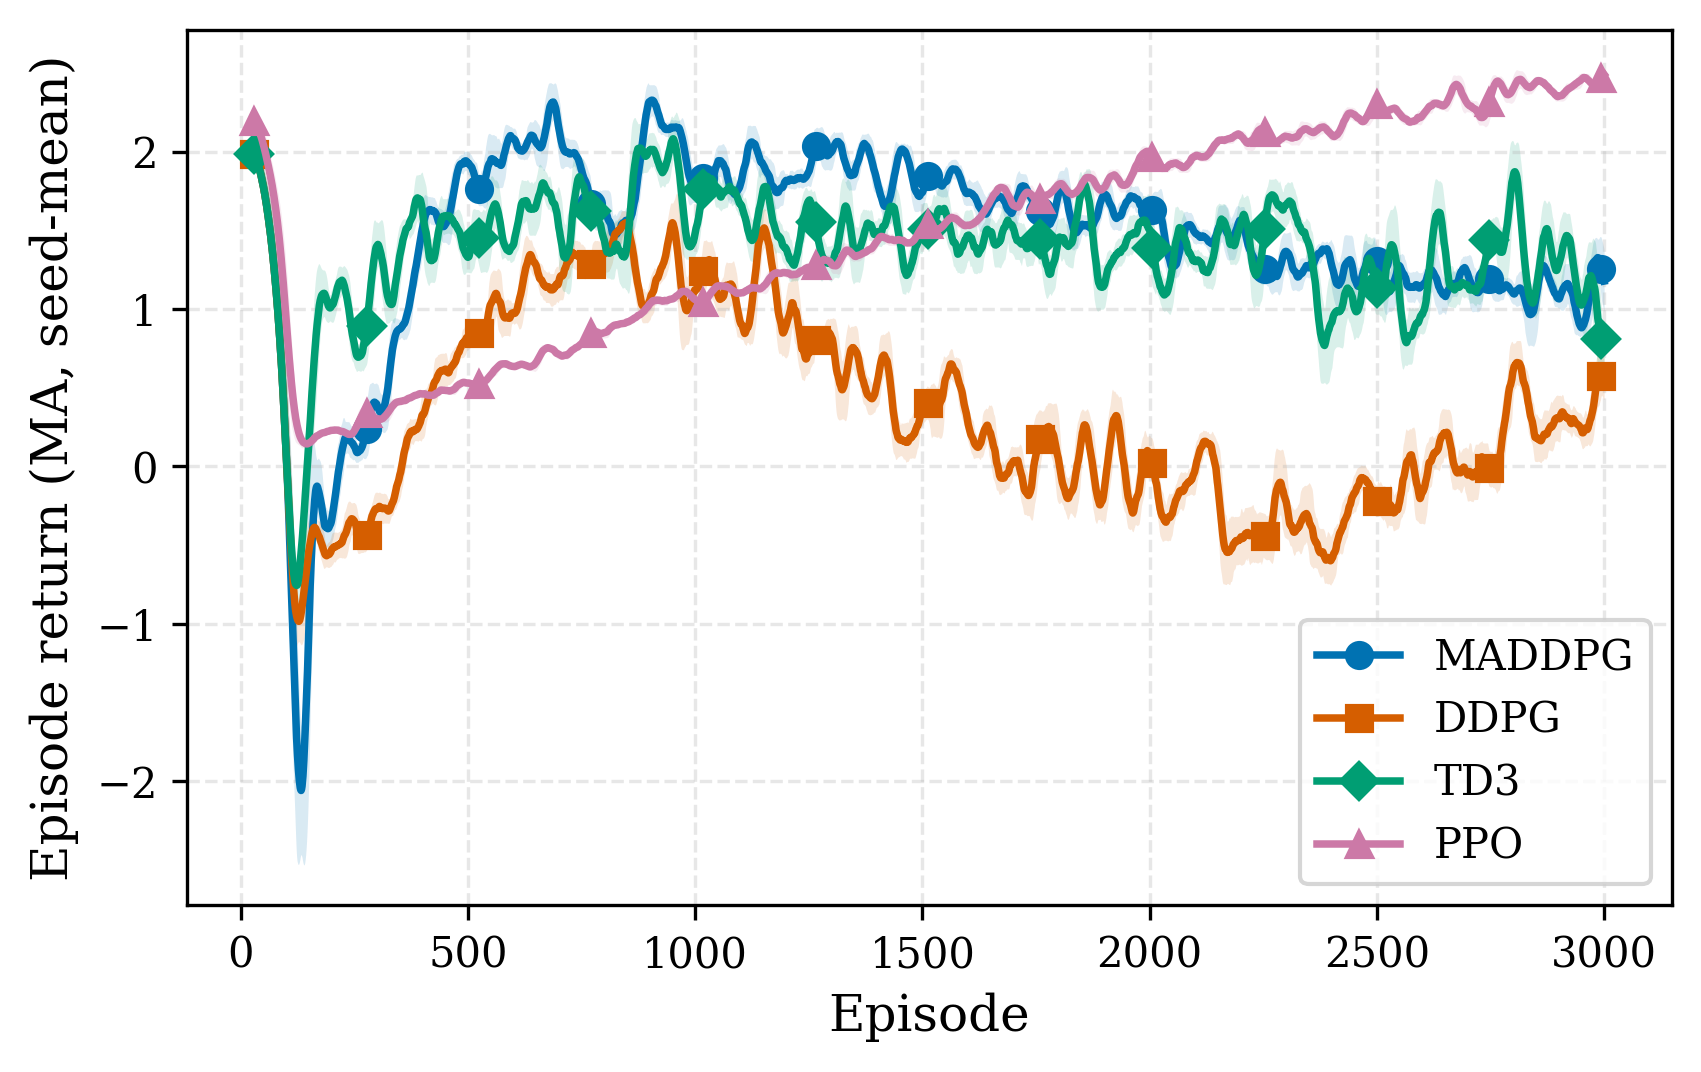


--- Đồ thị Sum-rate trung bình ---
  ✅ TỐT nếu: MADDPG đạt ~2.8 b/s/Hz và giữ phẳng
  ⚠️ CHƯA TỐT nếu: Đường vẫn đang leo dốc → cần thêm episodes


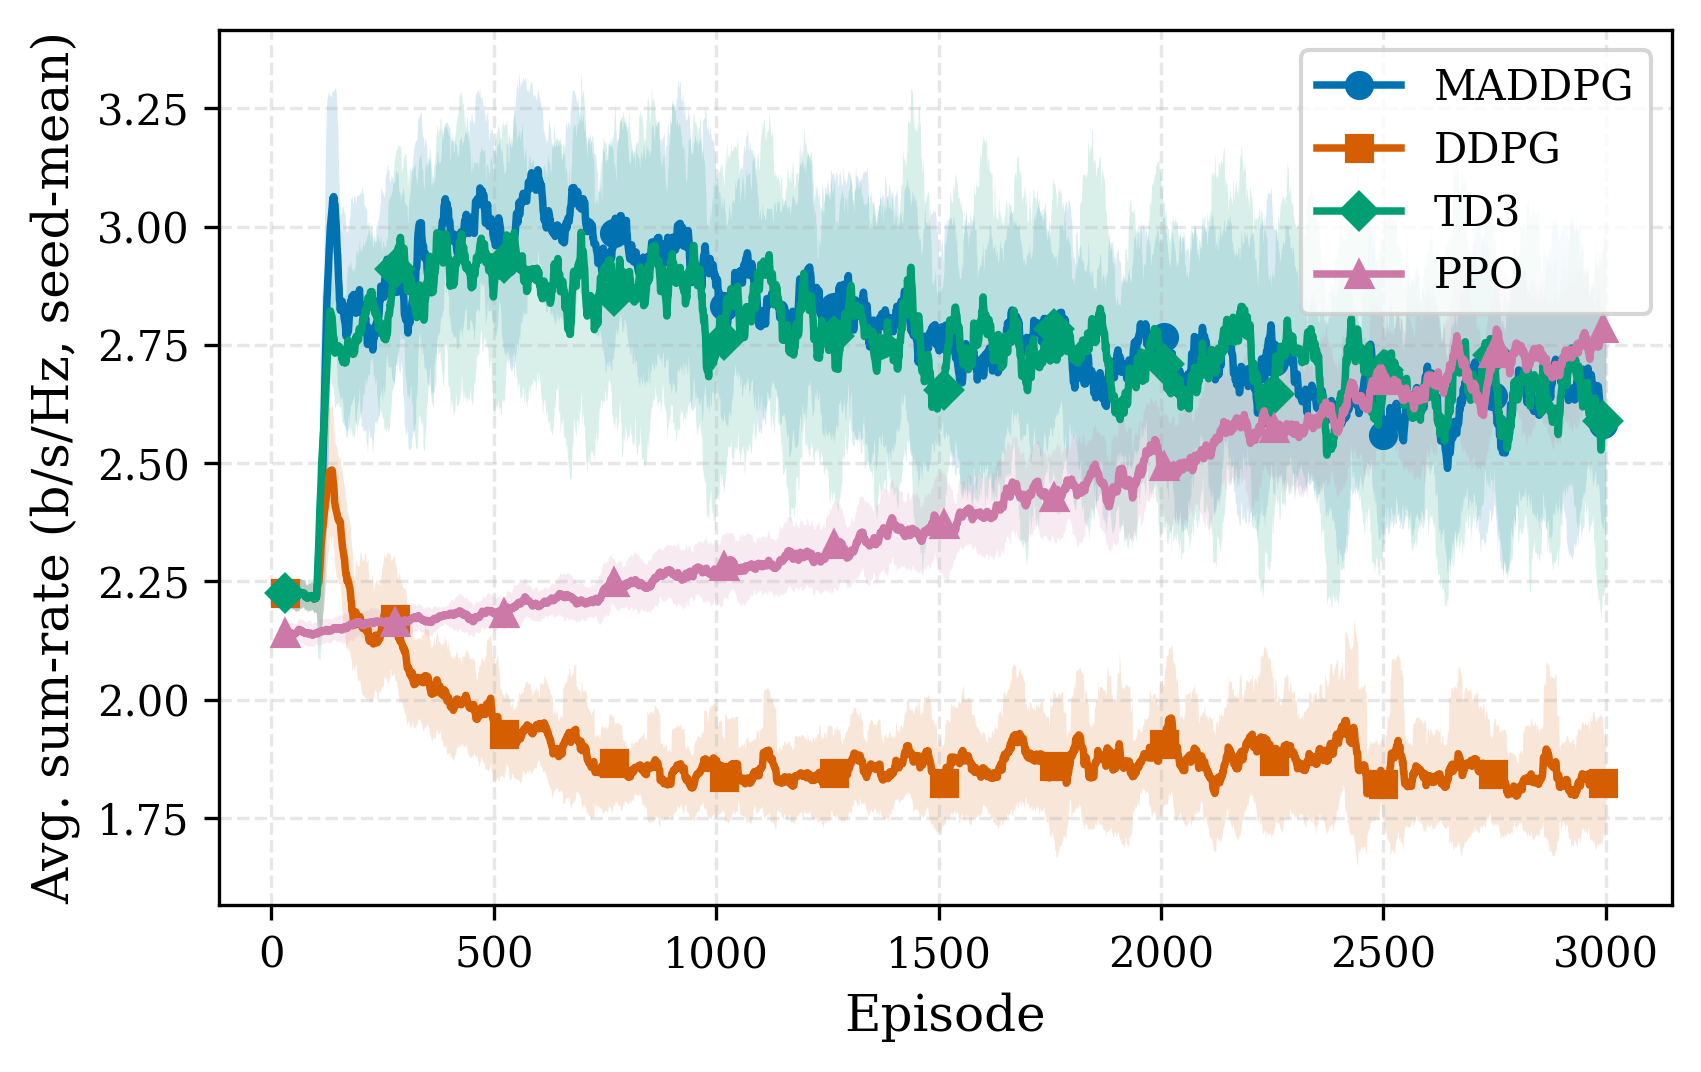


--- Đồ thị QoS Satisfaction ---
  ✅ TỐT nếu: MADDPG ổn định quanh 0.4-0.6 (cân bằng SR ↔ QoS)
  📋 GHI CHÚ: PPO đạt ~1.0 là degenerate policy (đã biết, disclosed trong paper)


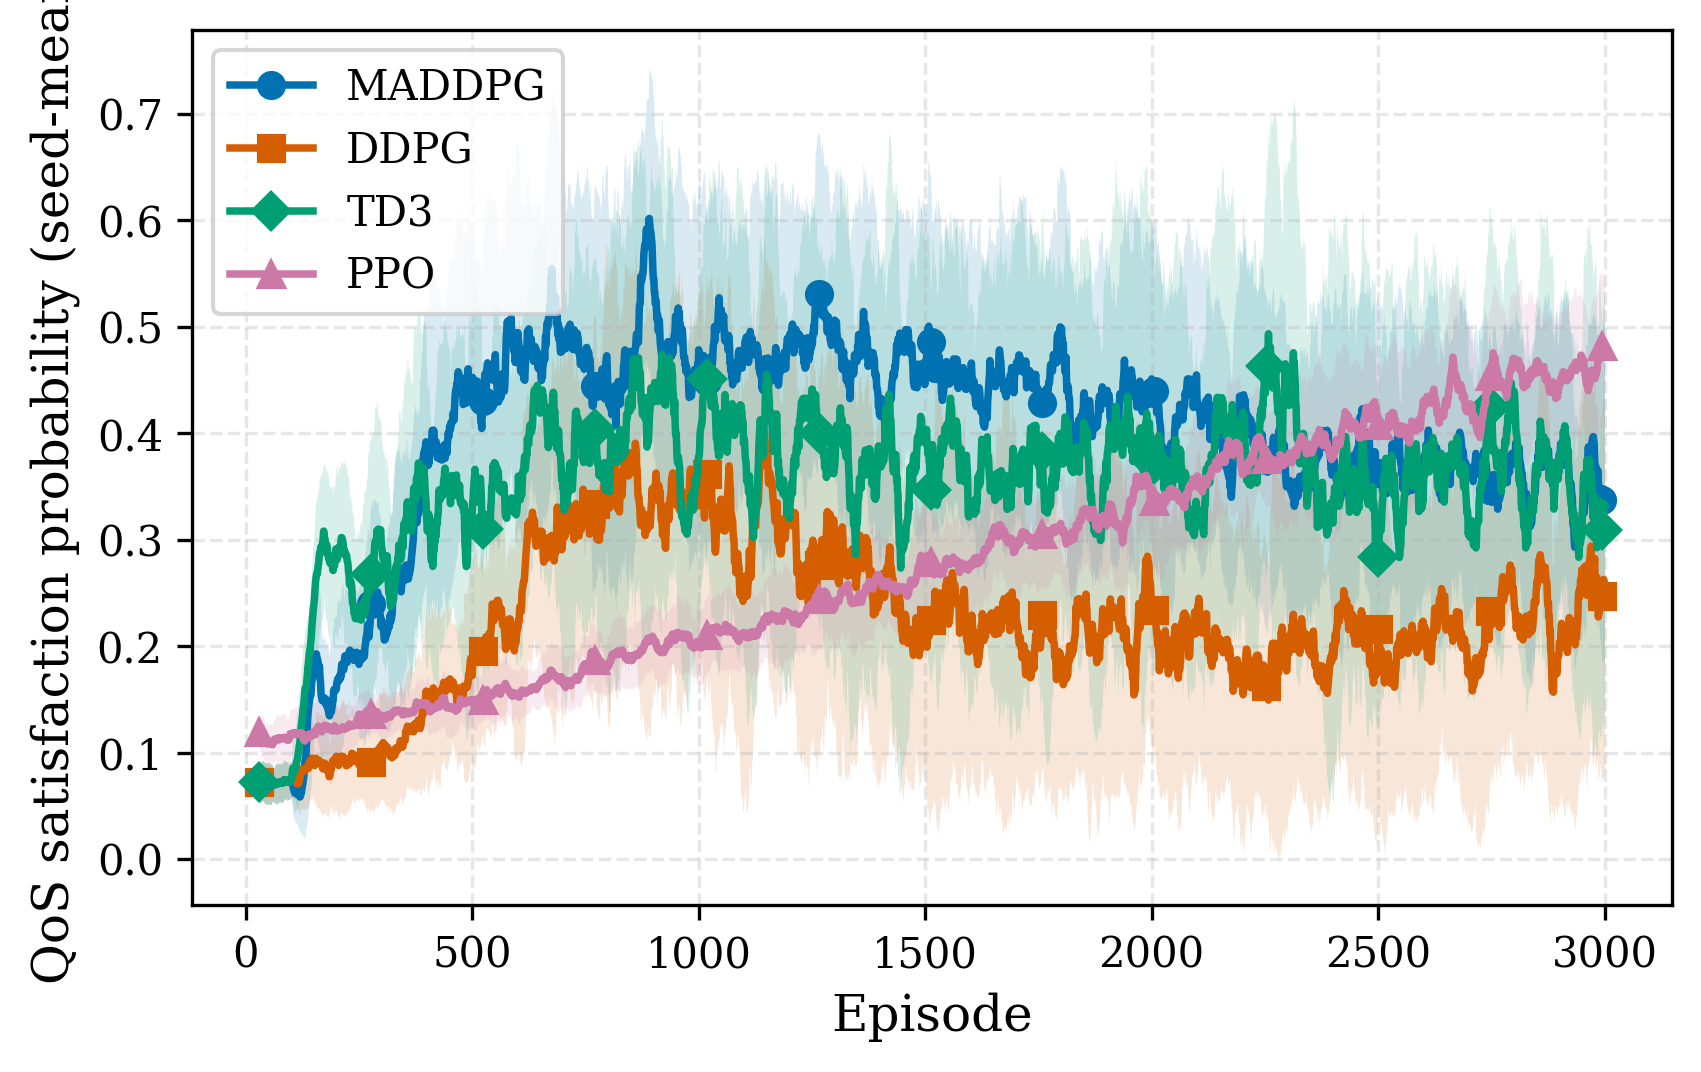


--- Đồ thị Tỷ lệ công suất dòng tin chung (P_c / P_max) ---
  ✅ TỐT nếu: MADDPG > 0.7 → agent phân bổ nhiều cho common stream
  📋 GHI CHÚ: PPO ~ 0.33 = phân bổ đều (1/(K+1)), đây là chính sách degenerate


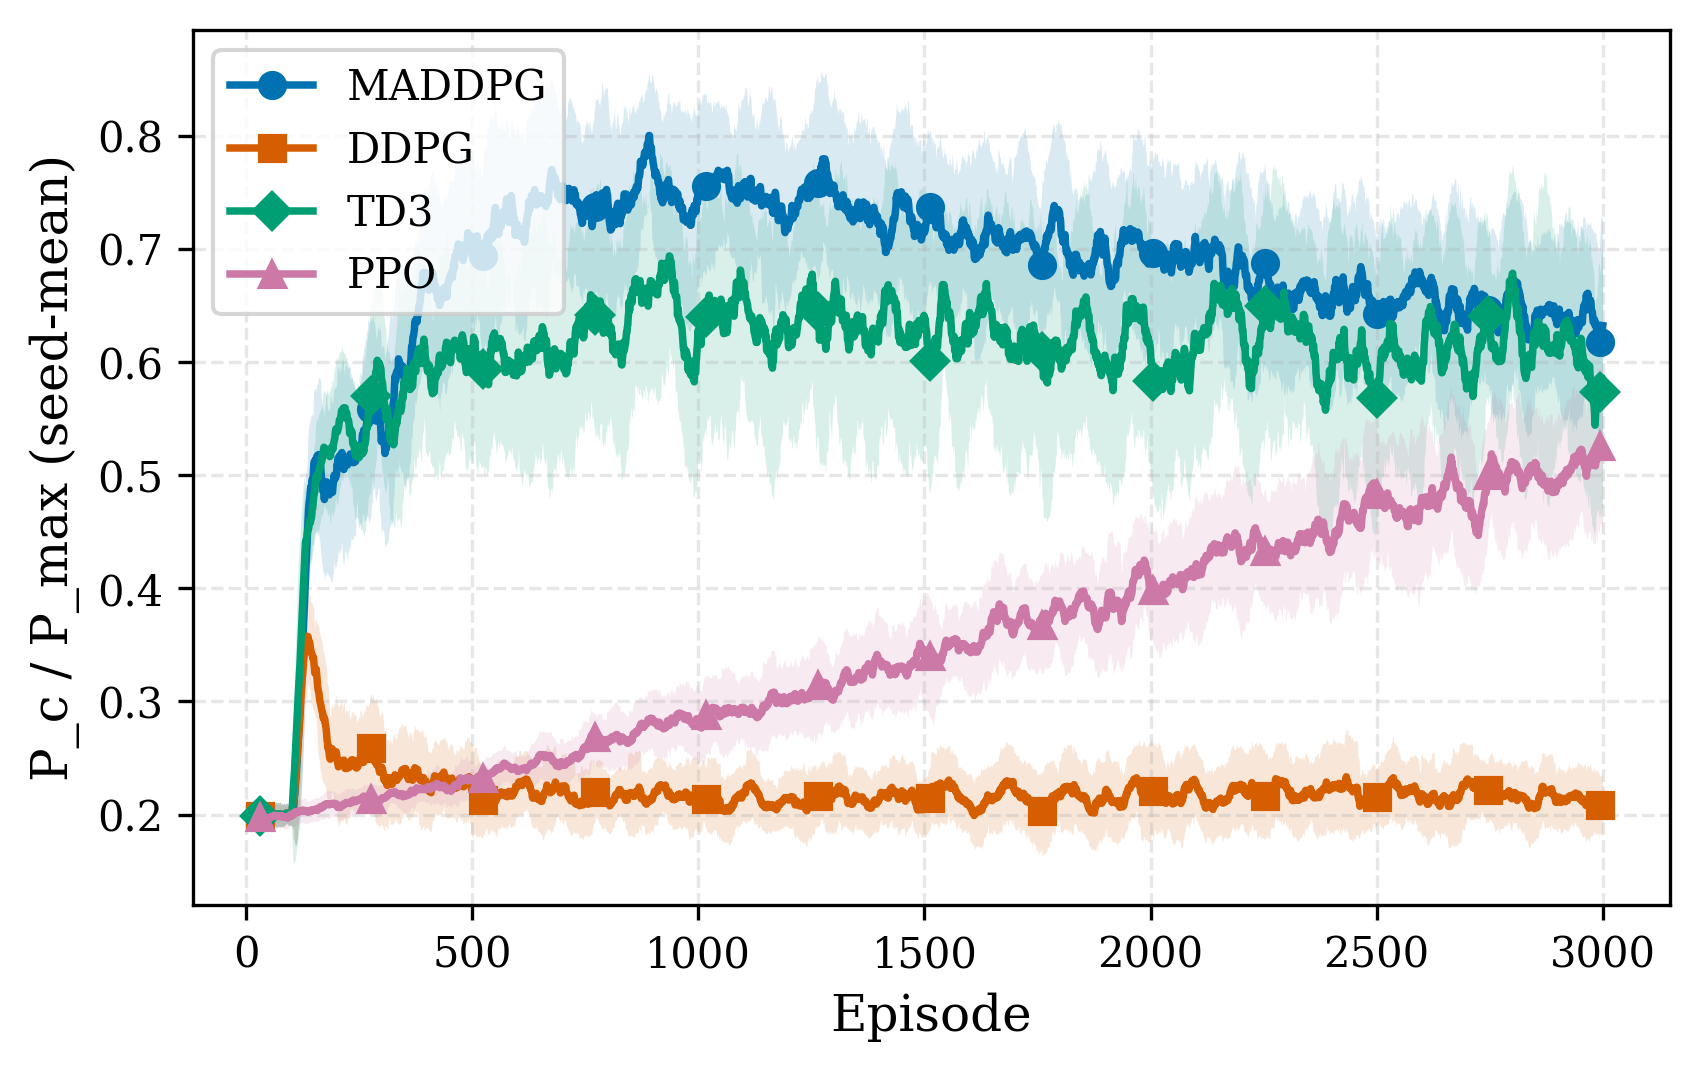

In [5]:
print("\n========== Đang tổng hợp và vẽ đồ thị hội tụ (Đa Seed) ==========")
def _seeds_curve(metric: str) -> dict[str, np.ndarray]:
    out = {}
    for algo, runs in trained.items():
        mat = []
        for info in runs:
            v = np.array(info["history"][metric], dtype=float)
            mat.append(v)
        min_len = min(len(v) for v in mat)
        mat = np.stack([v[:min_len] for v in mat], axis=0)   # (n_seeds, T)
        out[algo] = mat.mean(axis=0)
    return out

plot_training_convergence(_seeds_curve("ma_return"), out_dir=fig_dir,
                          name="training_convergence",
                          ylabel="Episode return (MA, seed-mean)")
plot_training_convergence(_seeds_curve("sum_rate"), out_dir=fig_dir,
                          name="training_sum_rate",
                          ylabel="Avg. sum-rate (b/s/Hz, seed-mean)")
plot_training_convergence(_seeds_curve("qos_satisfied"), out_dir=fig_dir,
                          name="training_qos_prob",
                          ylabel="QoS satisfaction probability (seed-mean)")
plot_training_convergence(_seeds_curve("common_power_frac"), out_dir=fig_dir,
                          name="training_common_power_frac",
                          ylabel="P_c / P_max (seed-mean)")

# Hiển thị ảnh trực tiếp
print("--- Đồ thị hội tụ Return (Moving Average) ---")
print("  ✅ TỐT nếu: Đường MADDPG phẳng ở 500 ep cuối, MA > 2.0")
print("  ⚠️ CHƯA TỐT nếu: Đường vẫn đang tăng/giảm rõ rệt ở ep 2500-3000")
display(Image(filename=os.path.join(fig_dir, "training_convergence.png")))

print("\n--- Đồ thị Sum-rate trung bình ---")
print("  ✅ TỐT nếu: MADDPG đạt ~2.8 b/s/Hz và giữ phẳng")
print("  ⚠️ CHƯA TỐT nếu: Đường vẫn đang leo dốc → cần thêm episodes")
display(Image(filename=os.path.join(fig_dir, "training_sum_rate.png")))

print("\n--- Đồ thị QoS Satisfaction ---")
print("  ✅ TỐT nếu: MADDPG ổn định quanh 0.4-0.6 (cân bằng SR ↔ QoS)")
print("  📋 GHI CHÚ: PPO đạt ~1.0 là degenerate policy (đã biết, disclosed trong paper)")
display(Image(filename=os.path.join(fig_dir, "training_qos_prob.png")))

print("\n--- Đồ thị Tỷ lệ công suất dòng tin chung (P_c / P_max) ---")
print("  ✅ TỐT nếu: MADDPG > 0.7 → agent phân bổ nhiều cho common stream")
print("  📋 GHI CHÚ: PPO ~ 0.33 = phân bổ đều (1/(K+1)), đây là chính sách degenerate")
display(Image(filename=os.path.join(fig_dir, "training_common_power_frac.png")))

### 6. Phân tích Adaptive QoS Lambda và Phân rã Phần thưởng (Reward Decomposition)

Phân tích cách tham số Lagrangian $\lambda$ thích ứng trong quá trình huấn luyện của MADDPG.

**📌 Output mong đợi:** 2 đồ thị — (1) λ theo episode, (2) Phân rã reward thành SR/QoS/Power.

**🔍 Cách đánh giá:**
- **λ curve**: Nên tăng dần và ổn định (bão hòa) ở 1/2 cuối training. Nếu λ vẫn dao động mạnh → QoS chưa cân bằng.
- **Reward decomposition**: `reward_sr` (xanh) nên dương và chiếm ưu thế, `reward_qos` (đỏ) nên âm nhẹ (phạt vi phạm QoS), `reward_pwr` (cam) nên gần 0 (không vi phạm công suất).


========== Vẽ đồ thị adaptive λ và phân rã reward cho MADDPG ==========
--- Adaptive QoS Lambda ---
  ✅ TỐT nếu: λ tăng dần rồi bão hòa (phẳng) ở nửa sau training
  ⚠️ Nếu λ chạm max=15 ngay từ đầu → agent đang bị phạt QoS quá nặng


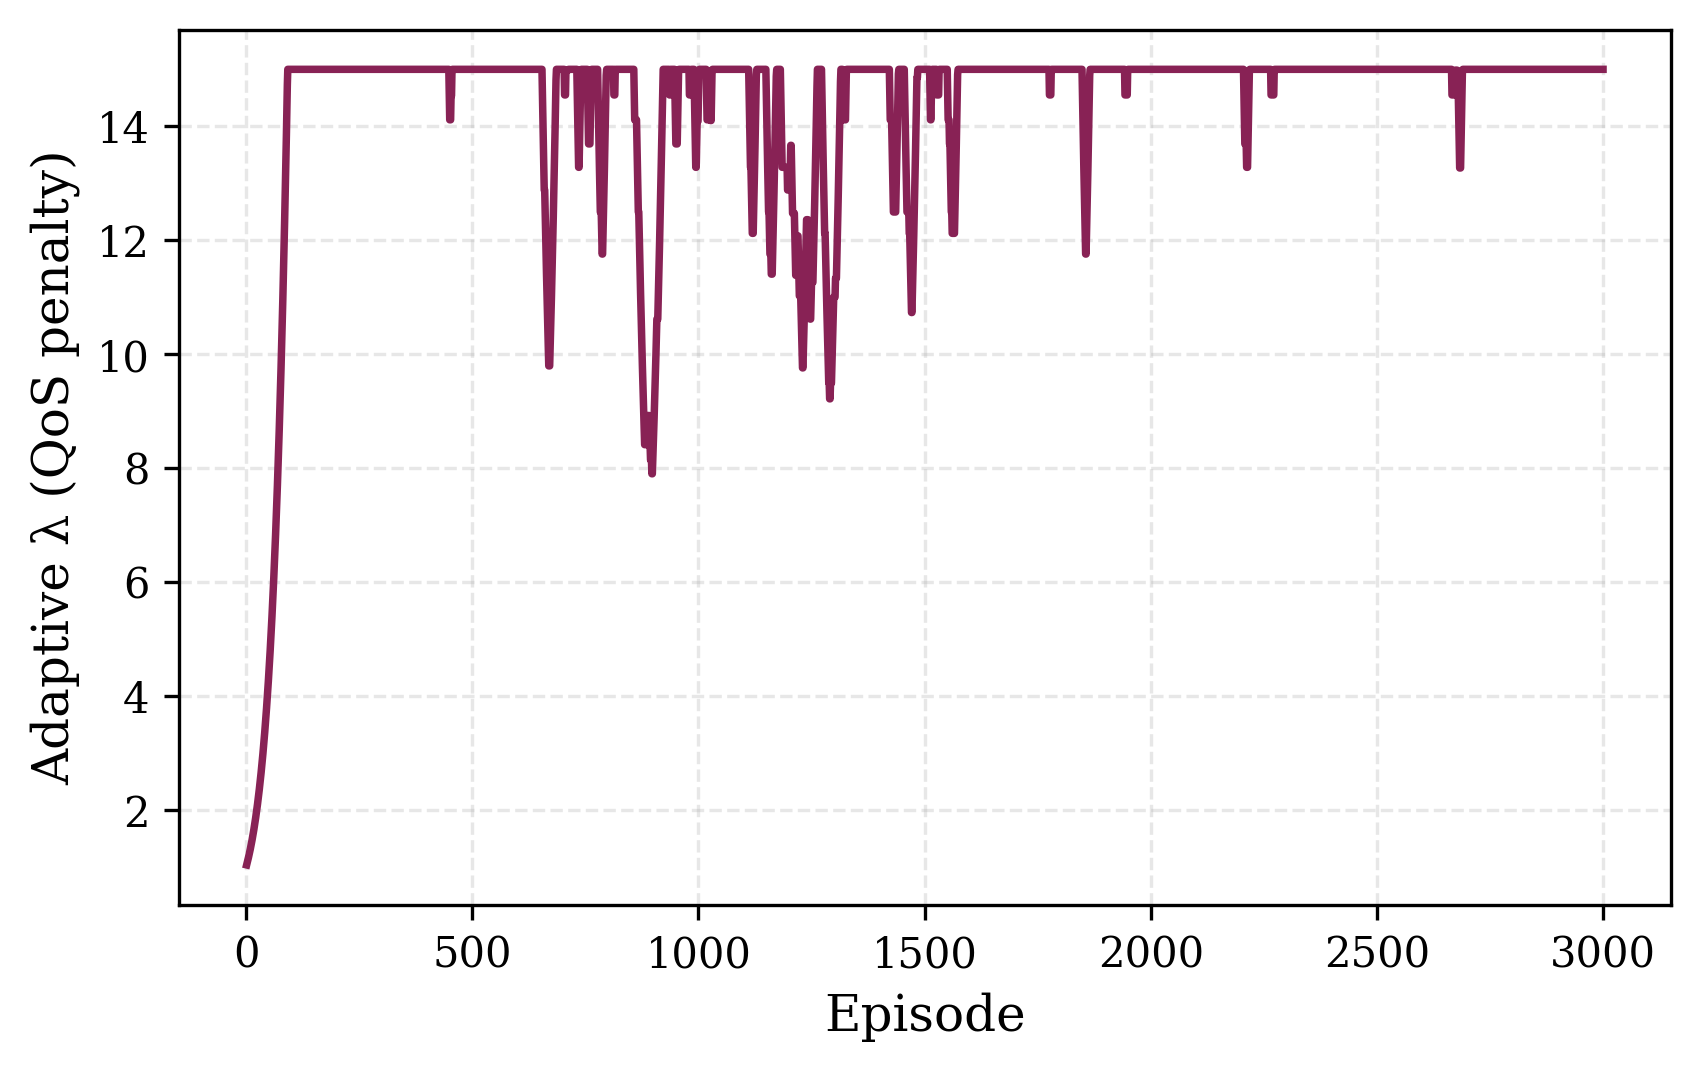


--- Phân rã phần thưởng (Reward Decomposition) ---
  ✅ TỐT nếu: reward_sr (xanh) dương, reward_qos (đỏ) âm nhẹ


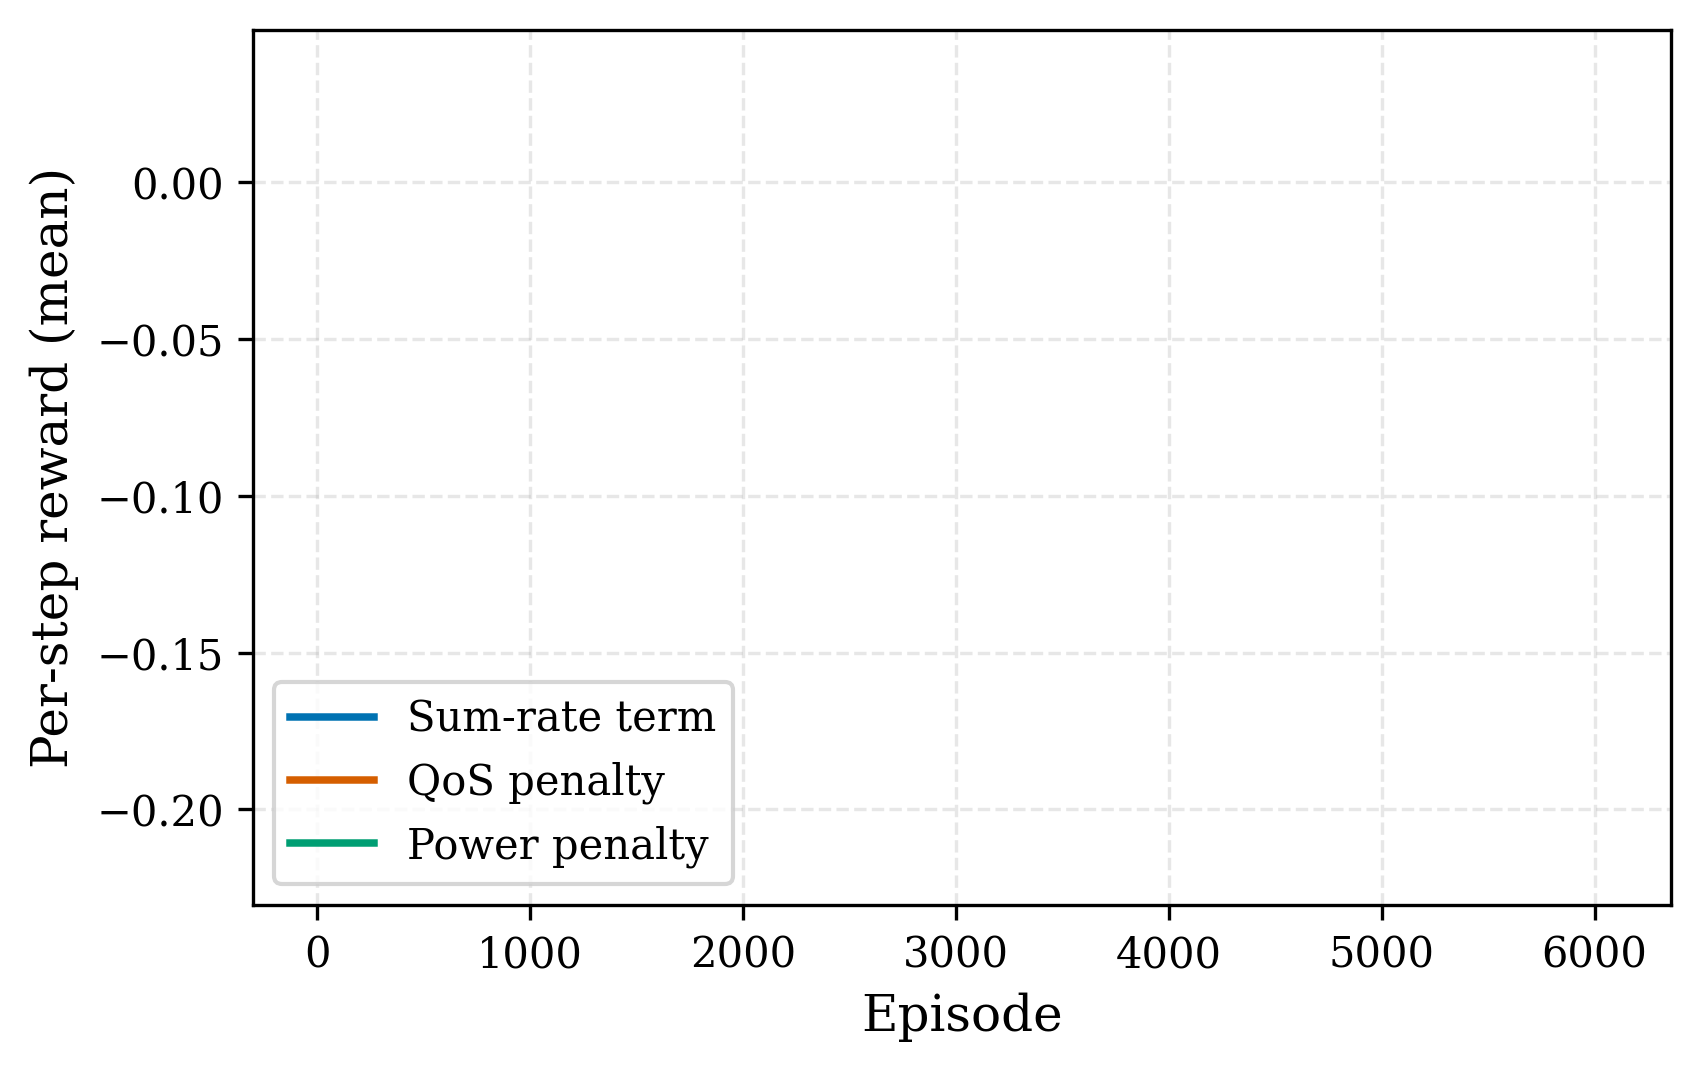

In [6]:
if "MADDPG" in trained:
    print("\n========== Vẽ đồ thị adaptive λ và phân rã reward cho MADDPG ==========")
    plot_qos_lambda(trained_main["MADDPG"]["history"], out_dir=fig_dir, name="qos_lambda")
    first_seed = training_seeds[0]
    log_csv = os.path.join(log_dir, f"maddpg_seed{first_seed}", "log.csv")
    if not os.path.exists(log_csv):
        log_csv = os.path.join(log_dir, f"MADDPG_seed{first_seed}", "log.csv")
    
    if os.path.exists(log_csv):
        df_log = pd.read_csv(log_csv)
        dec = {
            "reward_sr_mean":  df_log["reward_sr_mean"].values if "reward_sr_mean" in df_log else [],
            "reward_qos_mean": df_log["reward_qos_mean"].values if "reward_qos_mean" in df_log else [],
            "reward_pwr_mean": df_log["reward_pwr_mean"].values if "reward_pwr_mean" in df_log else [],
        }
        plot_reward_decomposition(dec, out_dir=fig_dir, name="reward_decomposition")
        
    # Hiển thị ảnh trực tiếp
    print("--- Adaptive QoS Lambda ---")
    print("  ✅ TỐT nếu: λ tăng dần rồi bão hòa (phẳng) ở nửa sau training")
    print("  ⚠️ Nếu λ chạm max=15 ngay từ đầu → agent đang bị phạt QoS quá nặng")
    display(Image(filename=os.path.join(fig_dir, "qos_lambda.png")))
    if os.path.exists(os.path.join(fig_dir, "reward_decomposition.png")):
        print("\n--- Phân rã phần thưởng (Reward Decomposition) ---")
        print("  ✅ TỐT nếu: reward_sr (xanh) dương, reward_qos (đỏ) âm nhẹ")
        display(Image(filename=os.path.join(fig_dir, "reward_decomposition.png")))
else:
    print("MADDPG không được huấn luyện, bỏ qua cell này.")

### 7. Đánh giá Sum-rate & QoS theo Công suất BS ($P_{\max}$)

Quét công suất BS từ 10 → 35 dBm để đánh giá khả năng thích ứng của các thuật toán.

**📌 Output mong đợi:** 2 đồ thị — (1) Sum-rate vs P_max, (2) QoS vs P_max

**🔍 Cách đánh giá:**
- MADDPG nên **vượt trội rõ ở P_max ≥ 25 dBm** (vùng RL có lợi thế lớn nhất)
- Ở P_max thấp (10-15 dBm), PPO có thể tốt hơn vì QoS dễ đạt với đều công suất
- FixedRIS nên thấp hơn MADDPG → chứng minh giá trị của learned RIS phases
- Khoảng CI hẹp → kết quả đáng tin cậy


========== Sweep: Sum-rate & QoS vs Pmax (Đa Seed CI) ==========
--- Sum-rate vs P_max ---
  ✅ TỐT nếu: MADDPG cao nhất ở P_max ≥ 25 dBm, vượt TD3 ở 30-35 dBm


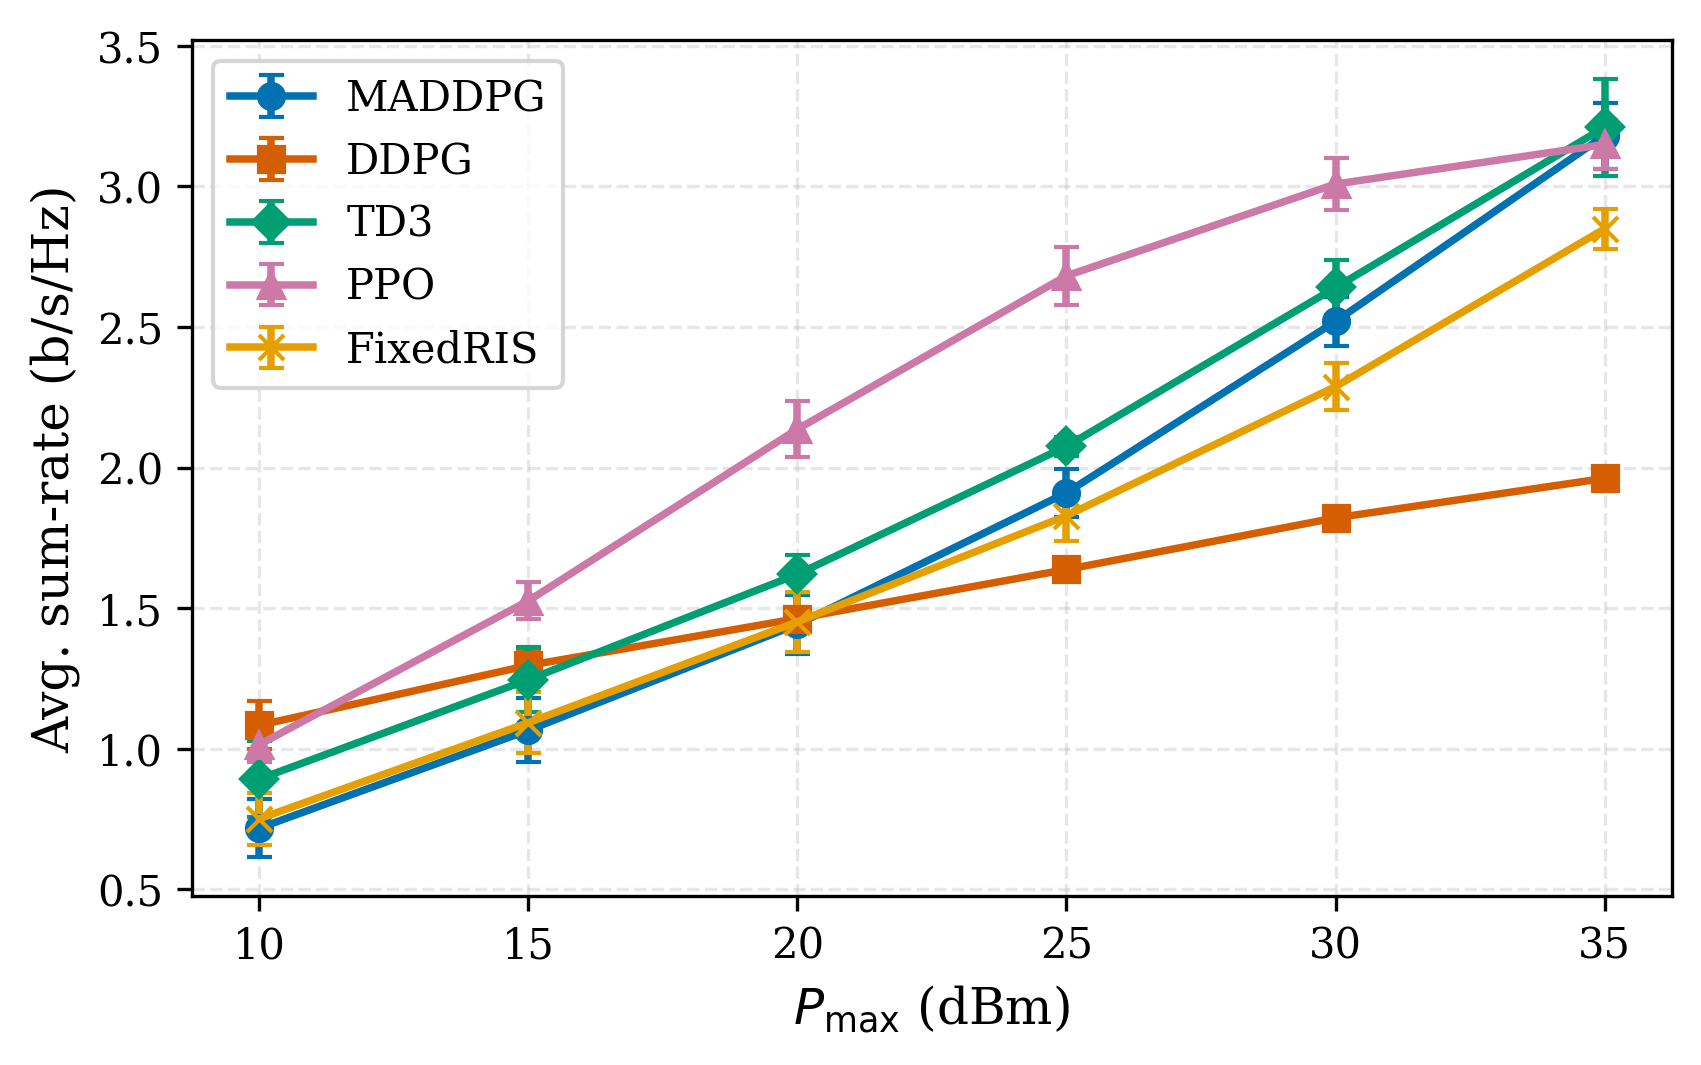


--- QoS vs P_max ---
  ✅ TỐT nếu: MADDPG QoS tăng theo P_max, cao hơn TD3 ở mọi điểm


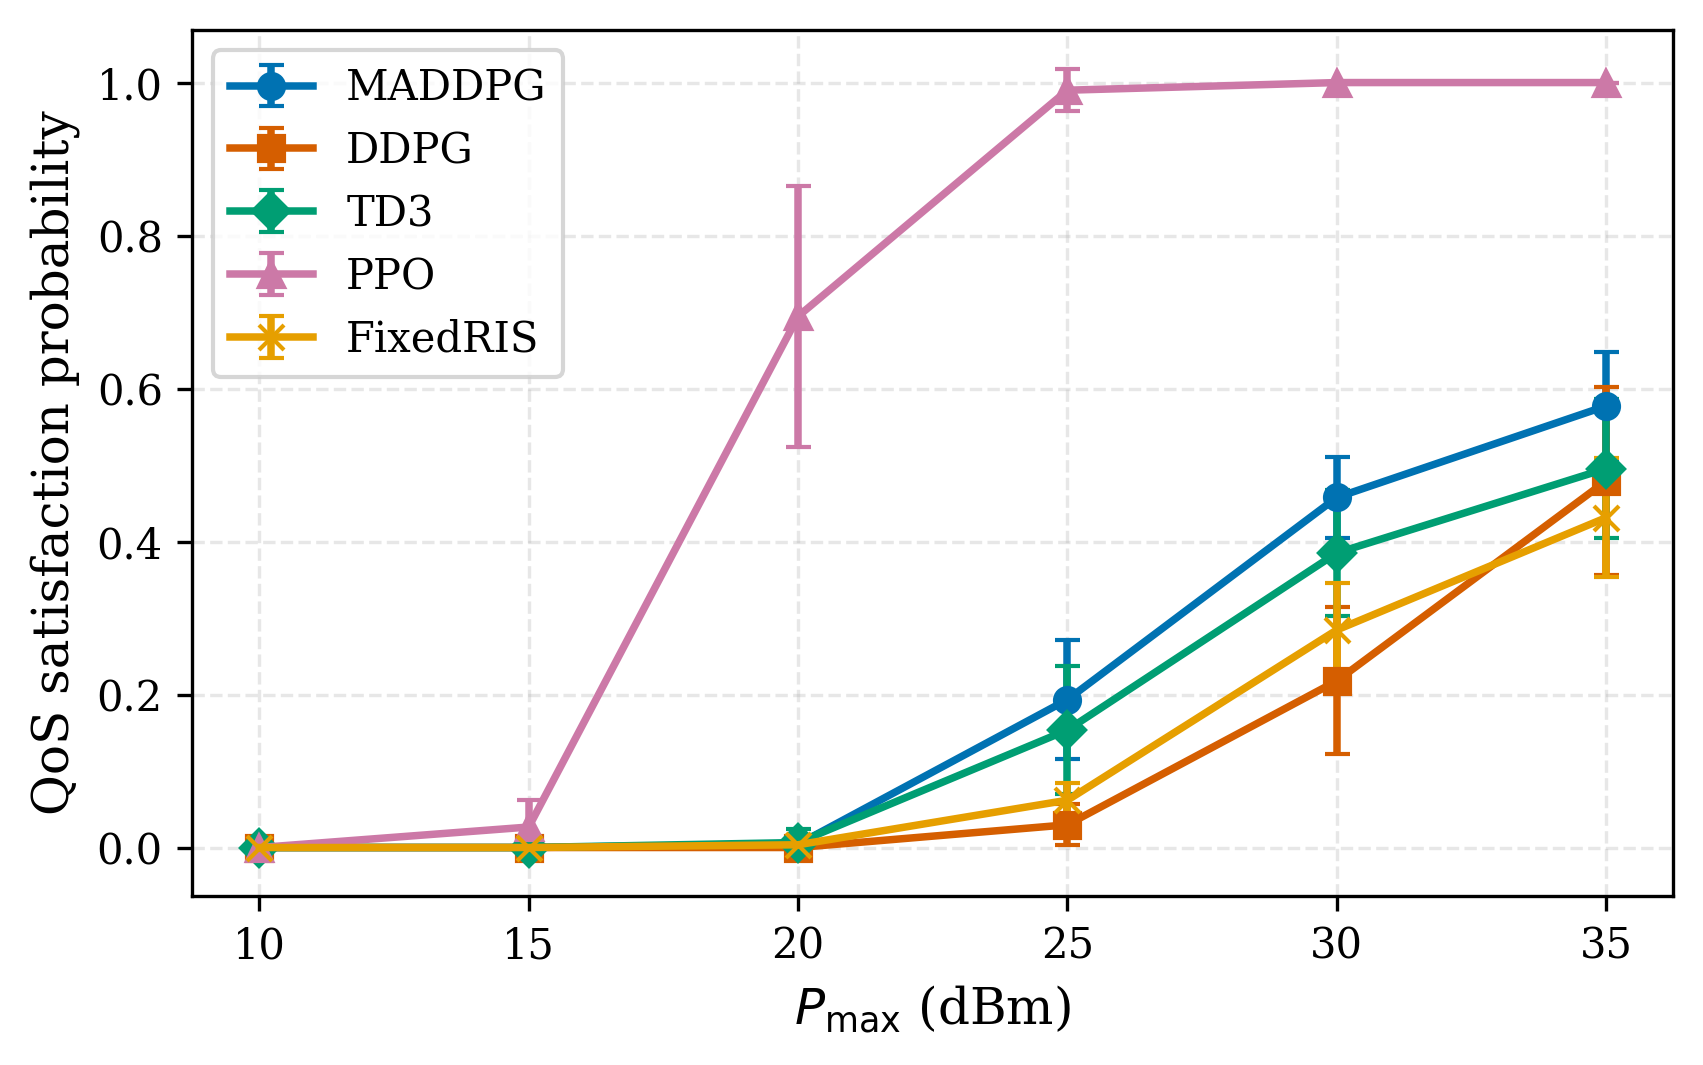

In [7]:
print("\n========== Sweep: Sum-rate & QoS vs Pmax (Đa Seed CI) ==========")
agents = {algo: info["agent"] for algo, info in trained_main.items()}
obs_norms = {algo: info["obs_norm"] for algo, info in trained_main.items()}
if "MADDPG" in trained_main:
    agents["FixedRIS"] = trained_main["MADDPG"]["agent"]
    obs_norms["FixedRIS"] = trained_main["MADDPG"]["obs_norm"]

sr_vs_p = sweep_power(agents, obs_norms, cfg)

plot_metric_vs_x(cfg["evaluation"]["power_sweep_dbm"], sr_vs_p,
                 xlabel="$P_{\\max}$ (dBm)", ylabel="Avg. sum-rate (b/s/Hz)",
                 out_dir=fig_dir, name="sumrate_vs_power")

qos_vs_p = {algo: {"x": cfg["evaluation"]["power_sweep_dbm"],
                   "mean": sr_vs_p[algo]["qos_mean"],
                   "ci":   sr_vs_p[algo]["qos_ci"]} for algo in sr_vs_p}
plot_metric_vs_x(cfg["evaluation"]["power_sweep_dbm"], qos_vs_p,
                 xlabel="$P_{\\max}$ (dBm)", ylabel="QoS satisfaction probability",
                 out_dir=fig_dir, name="qos_vs_power")

# Lưu CSV
pd.DataFrame({"Pmax_dBm": cfg["evaluation"]["power_sweep_dbm"],
              **{f"{a}_sr_mean": sr_vs_p[a]["mean"] for a in sr_vs_p},
              **{f"{a}_sr_ci":   sr_vs_p[a]["ci"]   for a in sr_vs_p}}
             ).to_csv(os.path.join(tab_dir, "sumrate_vs_power.csv"), index=False)

# Hiển thị
print("--- Sum-rate vs P_max ---")
print("  ✅ TỐT nếu: MADDPG cao nhất ở P_max ≥ 25 dBm, vượt TD3 ở 30-35 dBm")
display(Image(filename=os.path.join(fig_dir, "sumrate_vs_power.png")))
print("\n--- QoS vs P_max ---")
print("  ✅ TỐT nếu: MADDPG QoS tăng theo P_max, cao hơn TD3 ở mọi điểm")
display(Image(filename=os.path.join(fig_dir, "qos_vs_power.png")))

### 8. Đánh giá Xác suất QoS và Độ trễ suy luận (Inference Latency)

**📌 Output mong đợi:**
- **QoS bars**: MADDPG > TD3, PPO ~ 100% (degenerate)
- **Latency bars**: Tất cả < 2ms (đủ nhanh cho real-time wireless)

**🔍 Cách đánh giá:**
- MADDPG latency cao hơn (3 actors) nhưng vẫn < 2ms → chấp nhận được
- QoS MADDPG nên > 40% với CI hẹp


========== QoS satisfaction (Đa Seed Bars) ==========

========== Inference latency ==========
--- Xác suất QoS (mong đợi: MADDPG > TD3, PPO ≈ 100%) ---


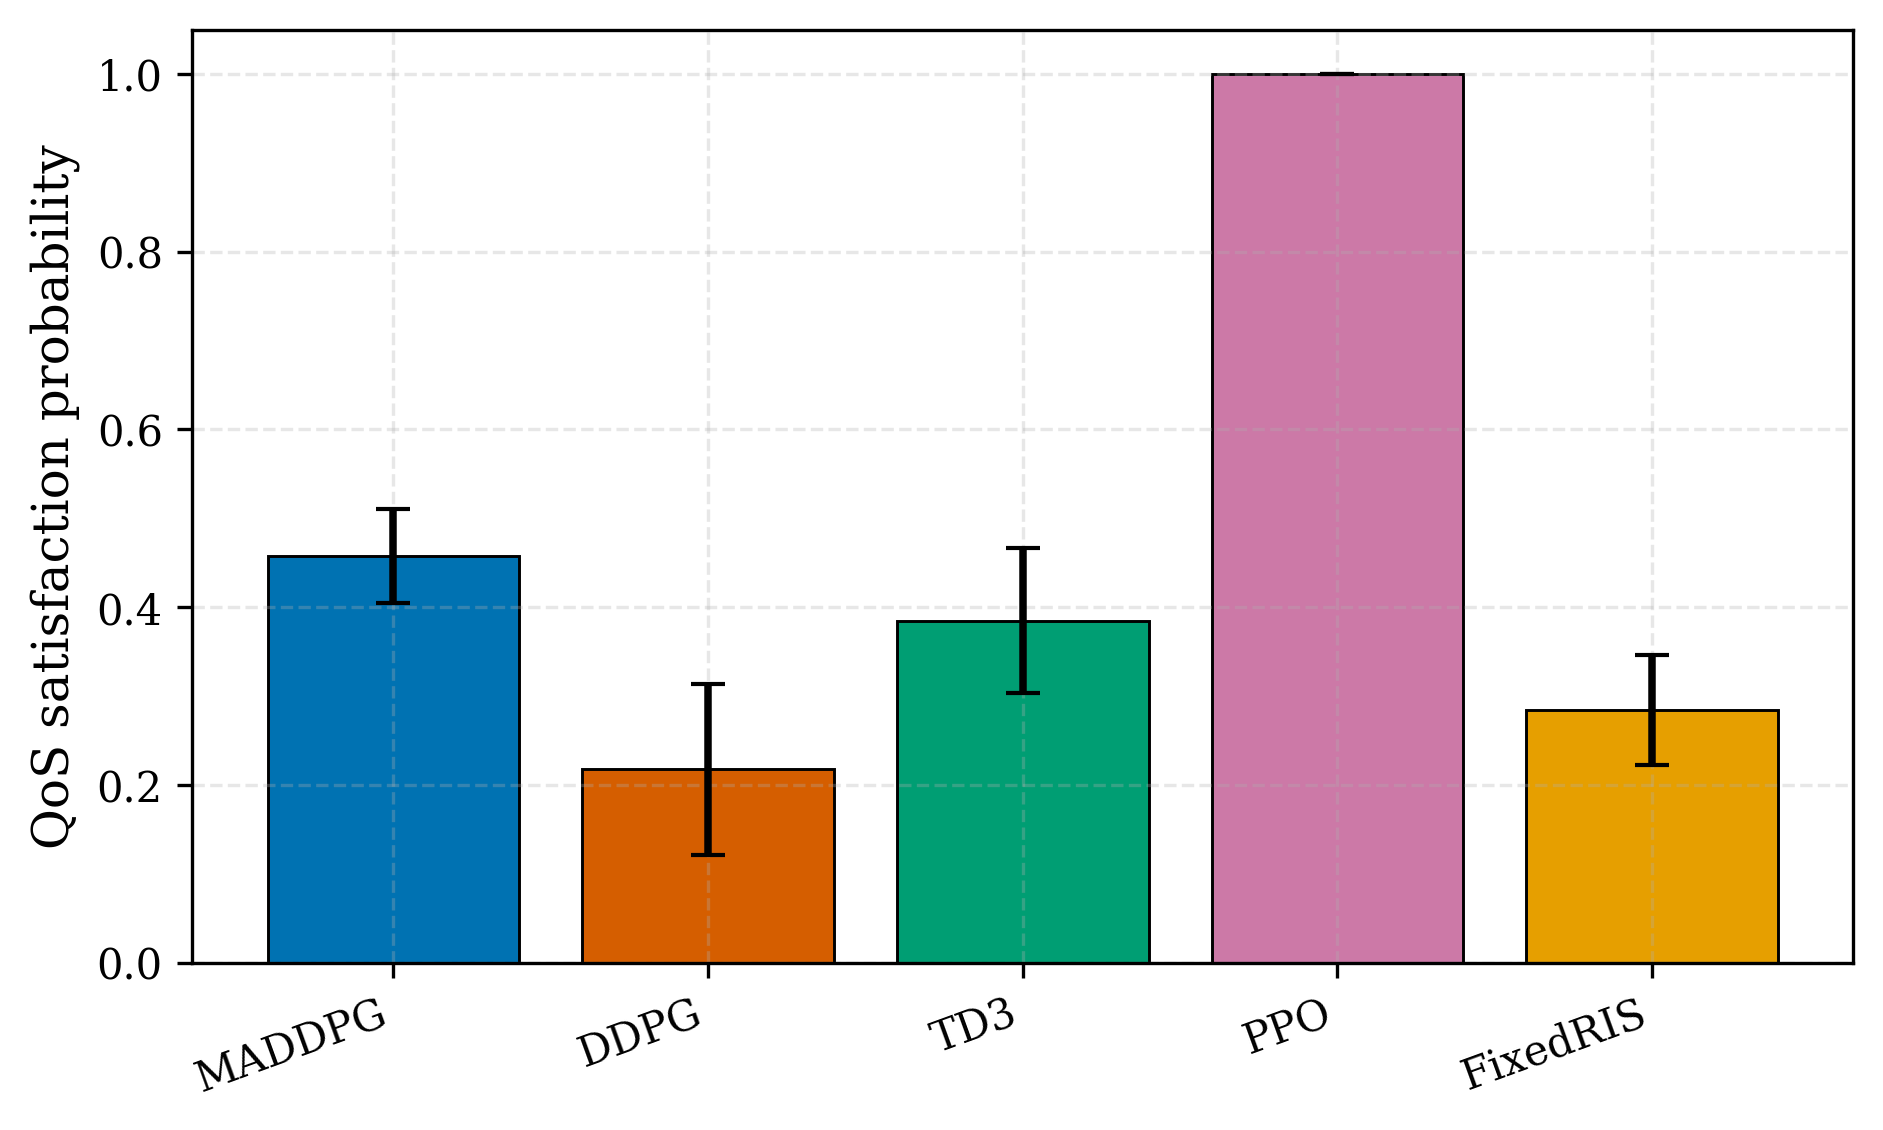


--- Độ trễ suy luận (mong đợi: tất cả < 2ms) ---


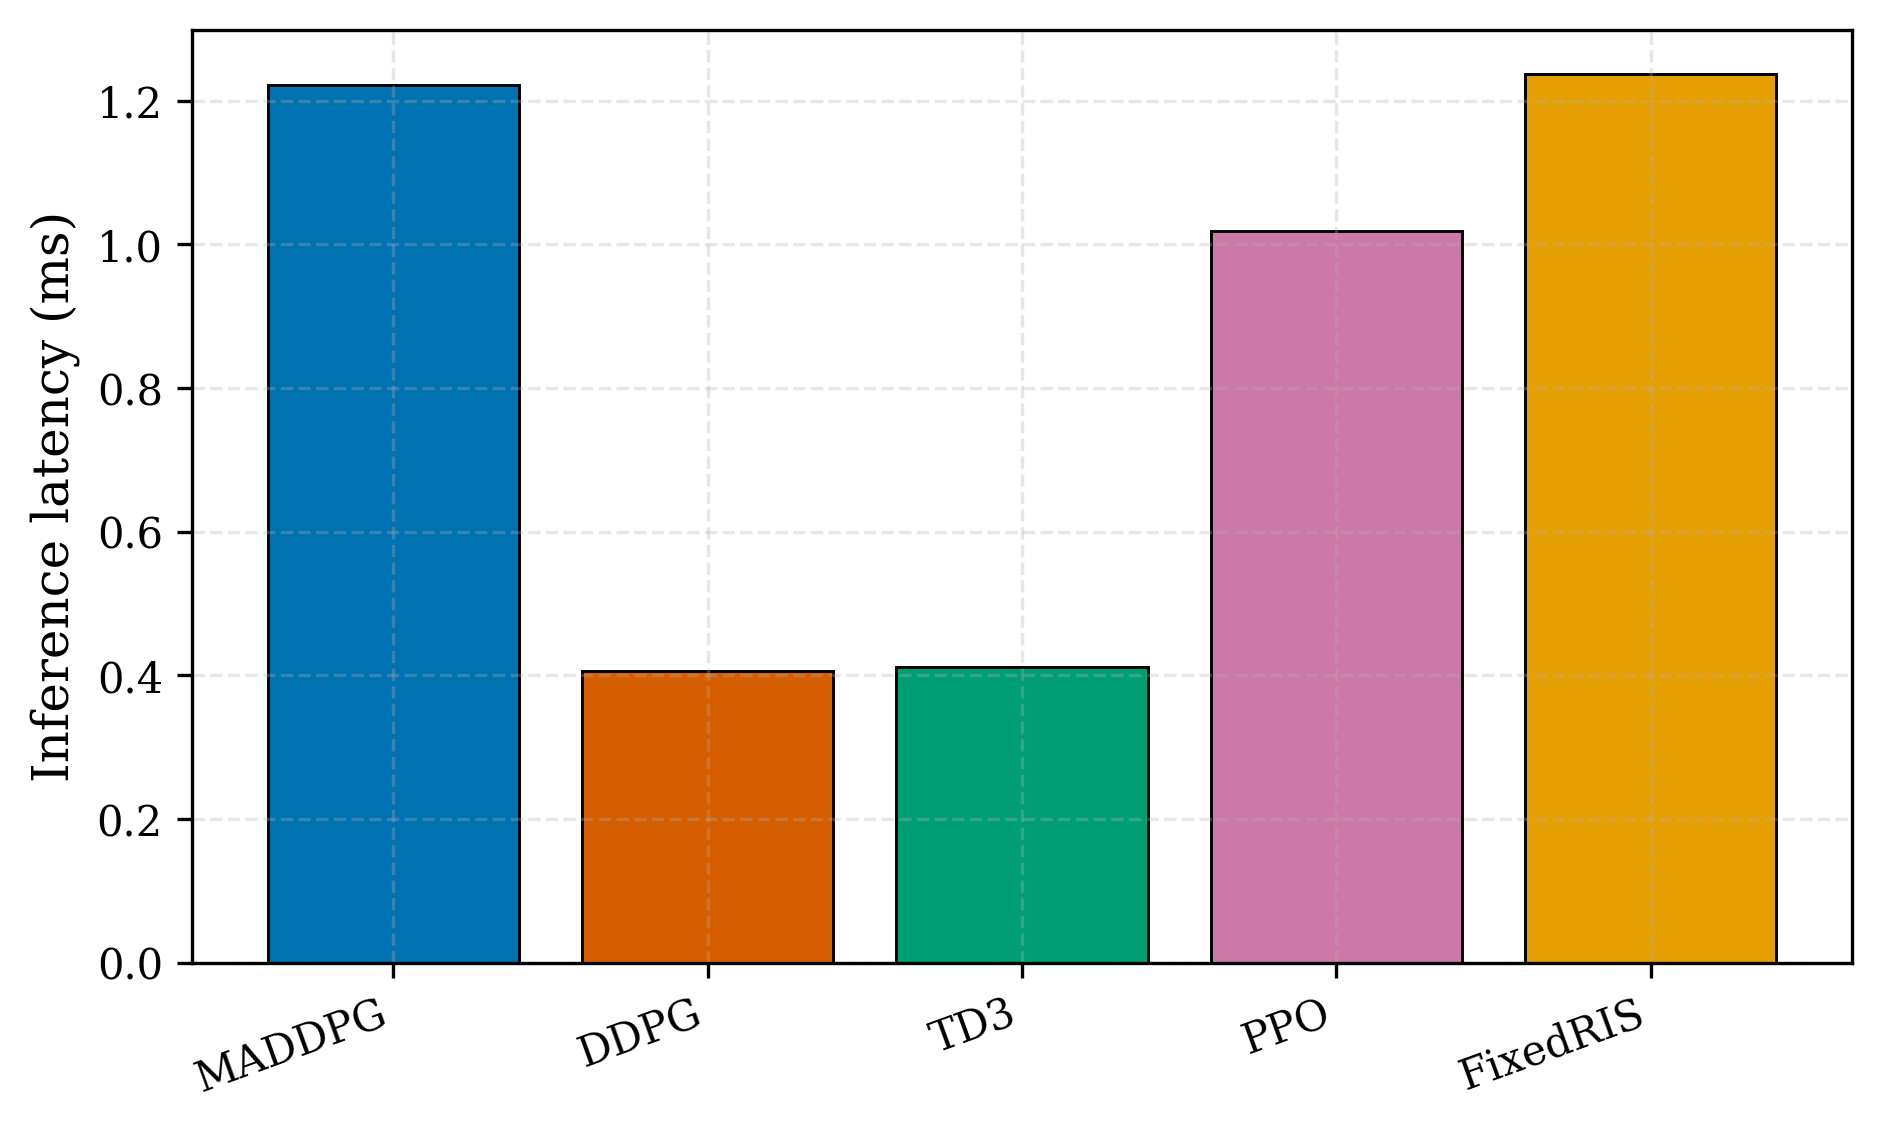

In [8]:
print("\n========== QoS satisfaction (Đa Seed Bars) ==========")
qos = qos_satisfaction(agents, obs_norms, cfg)
plot_bar(list(qos.keys()), {k: v["mean"] for k, v in qos.items()},
         out_dir=fig_dir, name="qos_probability",
         ylabel="QoS satisfaction probability",
         ci={k: v["ci"] for k, v in qos.items()})

print("\n========== Inference latency ==========")
lat = latency_benchmark(agents, obs_norms, cfg)
plot_bar(list(lat.keys()), lat, out_dir=fig_dir, name="latency",
         ylabel="Inference latency (ms)")

print("--- Xác suất QoS (mong đợi: MADDPG > TD3, PPO ≈ 100%) ---")
display(Image(filename=os.path.join(fig_dir, "qos_probability.png")))
print("\n--- Độ trễ suy luận (mong đợi: tất cả < 2ms) ---")
display(Image(filename=os.path.join(fig_dir, "latency.png")))

### 9. Nghiên cứu Loại bỏ (Ablation Study) — 8 cấu hình

Ablation study isolate từng thành phần của hệ thống:

| Cấu hình | RIS | BS Power | Mục đích kiểm chứng |
|---|---|---|---|
| **Learned** | RL learned | RL learned | Hệ thống đề xuất đầy đủ |
| **BCD** | BCD optimized | BCD optimized | Upper bound (tối ưu truyền thống) |
| **MaxMinAlignedRIS** | Analytical | RL learned | Giá trị của learned RIS vs giải tích |
| **FixedRIS** | Fixed (φ=0) | RL learned | Giá trị của RIS optimization |
| **RandomRIS** | Random | RL learned | Baseline RIS ngẫu nhiên |
| **NoRIS** | Disabled | RL learned | Giá trị của STAR-RIS |
| **EqPwr+Learned** | RL learned | Equal split | Giá trị của learned power allocation |
| **EqPwr+Fixed** | Fixed | Equal split | Baseline thấp nhất |

**📌 Output mong đợi:**
- **Learned > FixedRIS > NoRIS** (chứng minh RIS + RL optimization có giá trị)
- **BCD >> Learned** (BCD là upper bound, gap ~40-50% là bình thường)
- **Learned > EqPwr+Learned** (chứng minh giá trị của learned power allocation)


========== Nghiên cứu loại bỏ (Ablation Study - 8 cells) ==========
--- Sum-rate Ablation (mong đợi: BCD > Learned > Fixed > NoRIS) ---


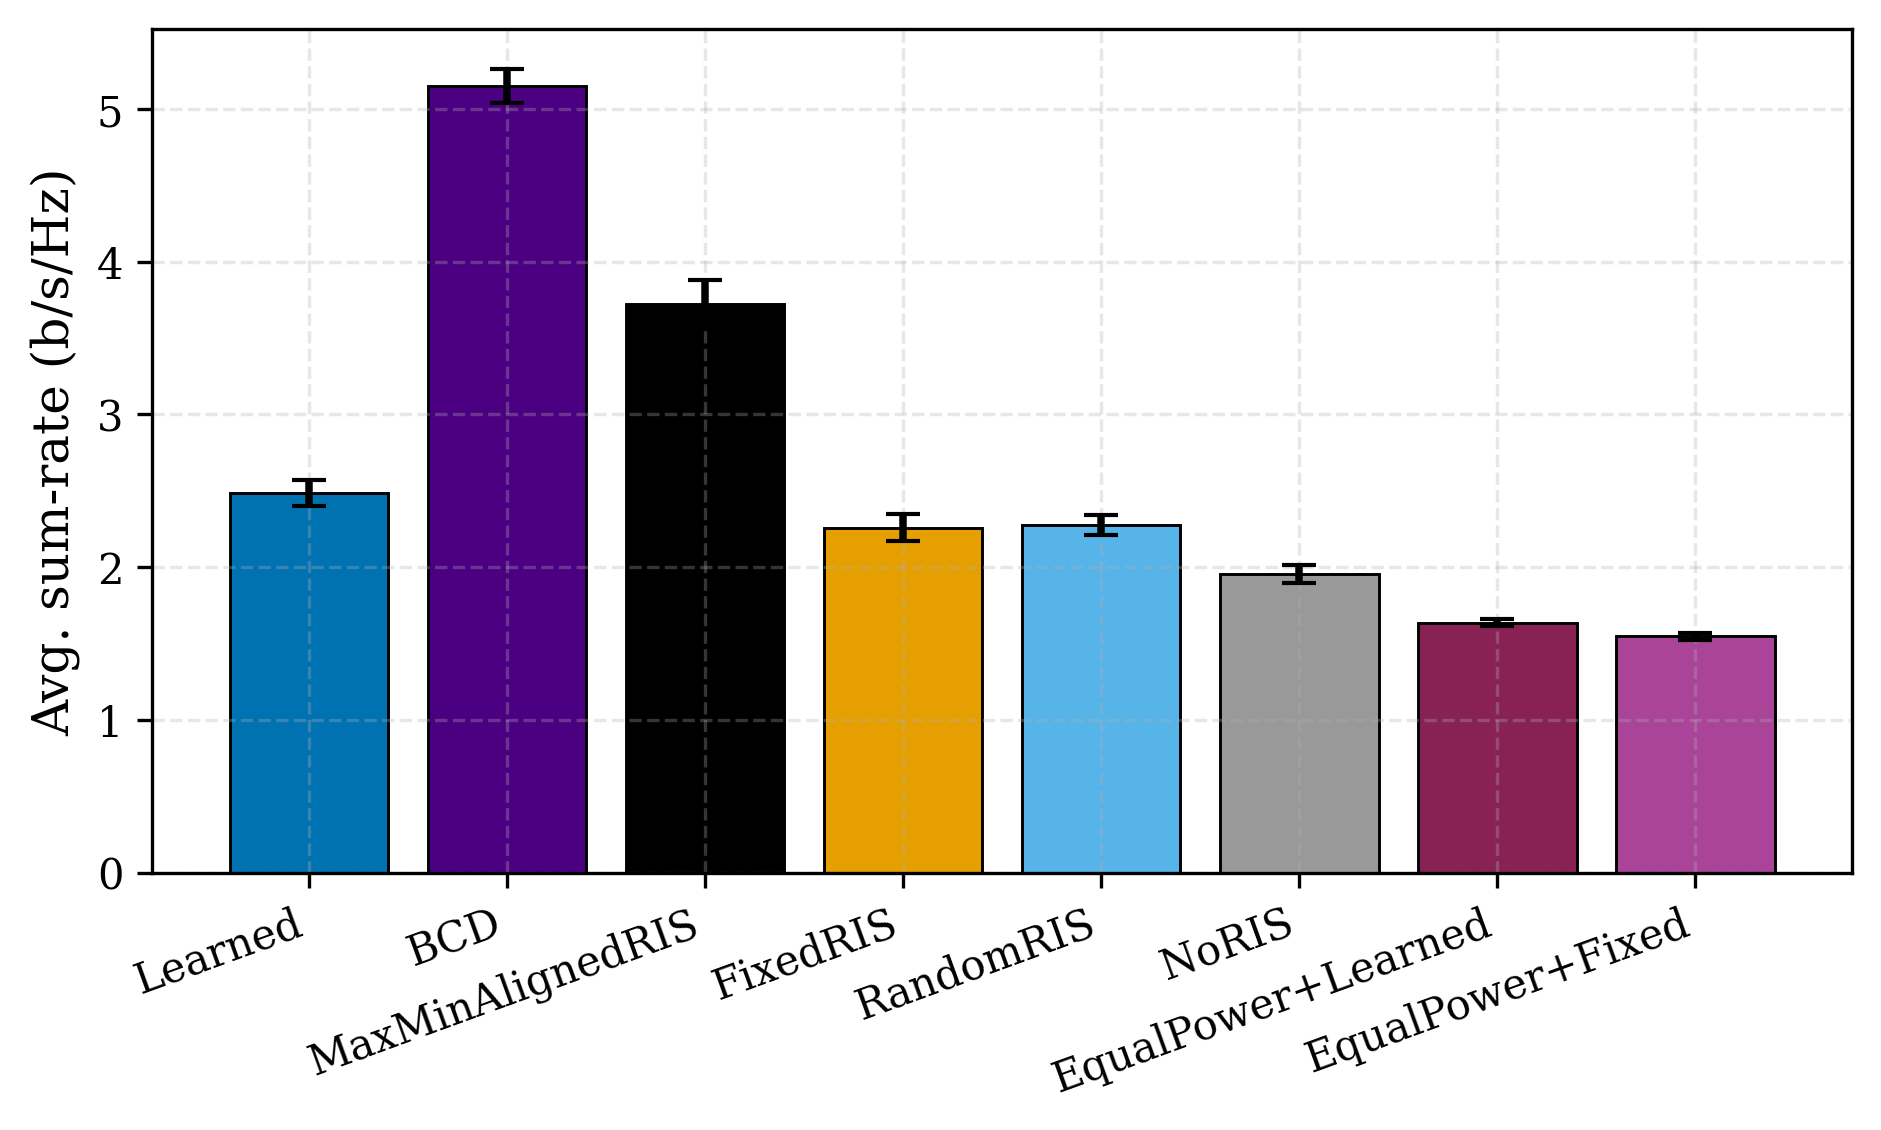

--- QoS Ablation ---


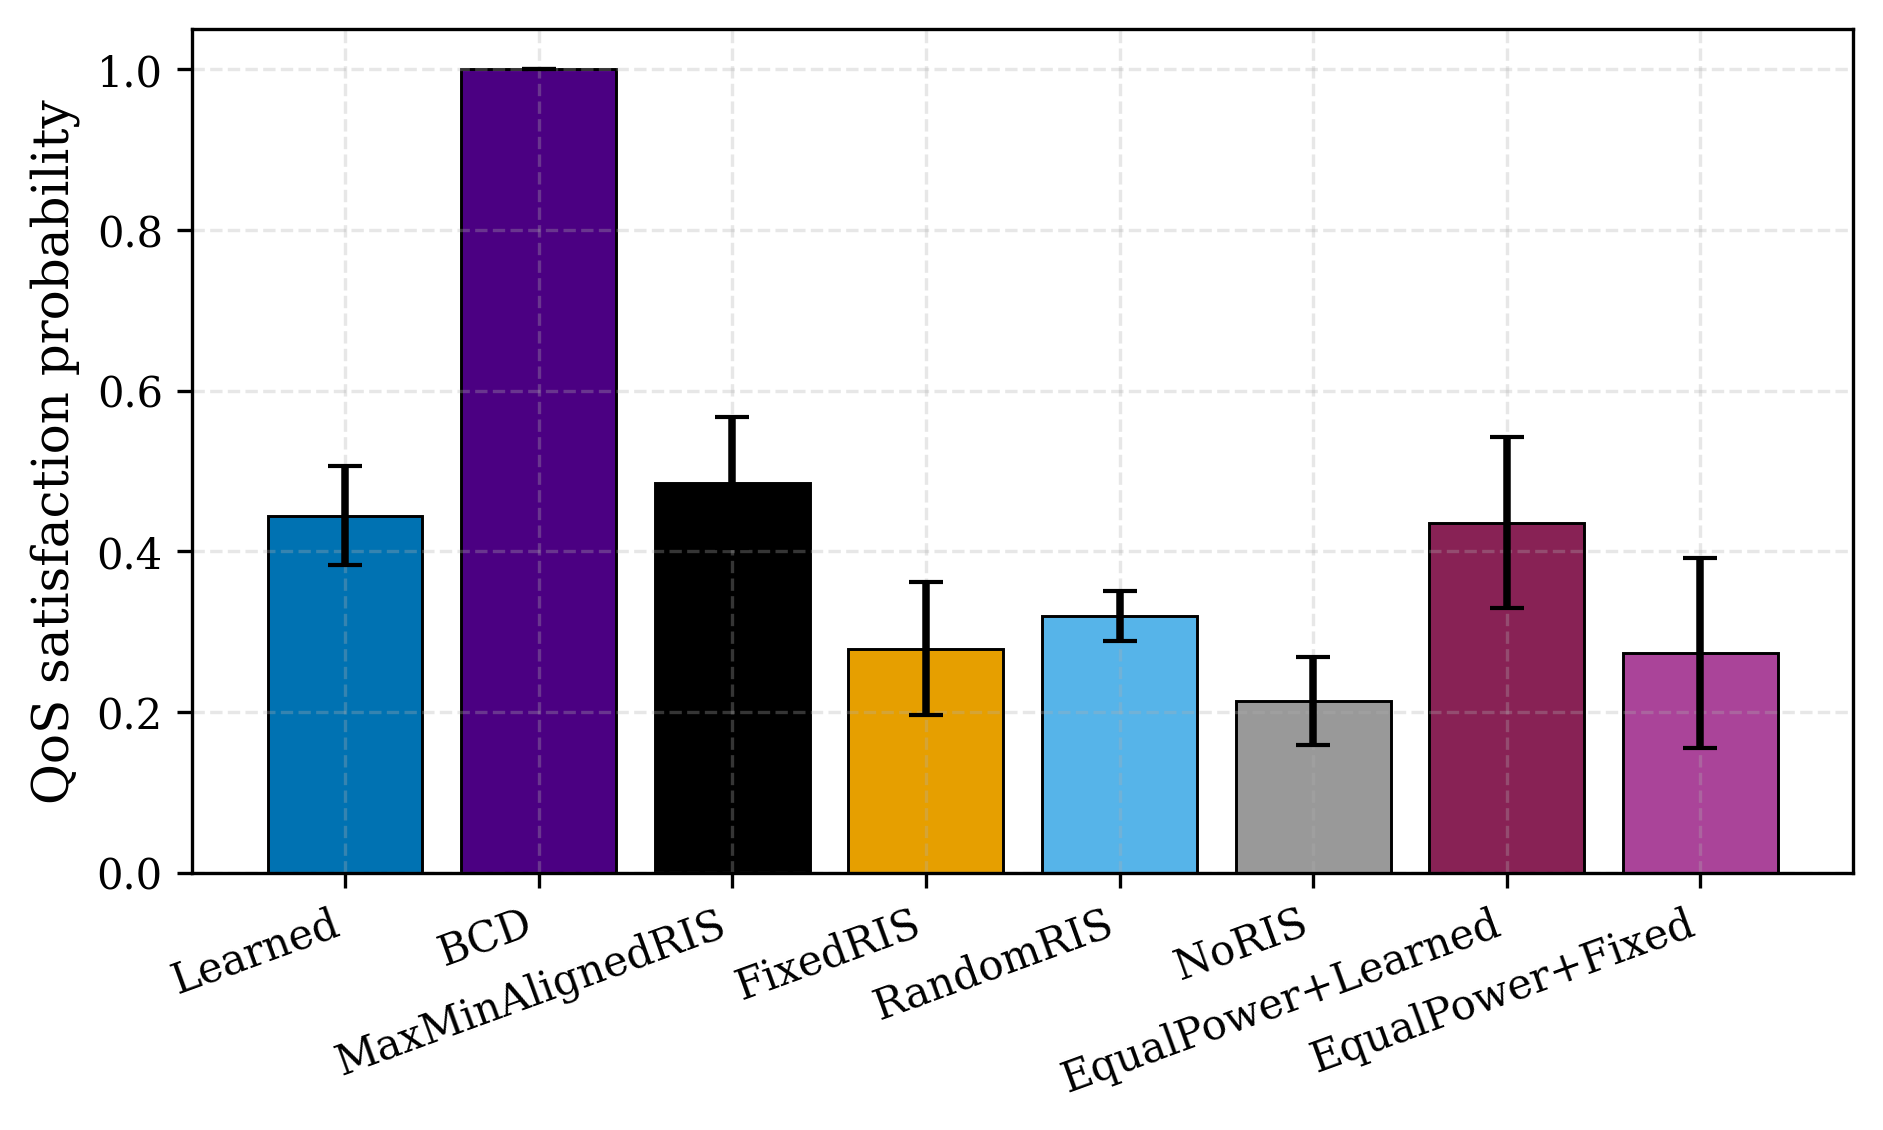


--- Bảng kết quả Ablation Study ---


,Cell,SumRate_mean,SumRate_CI95,QoS_mean,QoS_CI95,RateCommon,|h_eff_T|,PhaseEntropy_T,P_c/Pmax
0,Learned,2.487043,0.084768,0.444400,0.061348,0.915681,0.000002,2.504830,0.692205
1,BCD,5.147698,0.111227,1.000000,0.000000,3.711474,0.000009,2.502852,0.950000
2,MaxMinAlignedRIS,3.724193,0.158792,0.485733,0.081218,1.765031,0.000007,2.502852,0.648078
3,FixedRIS,2.259449,0.090969,0.278933,0.082399,0.655699,0.000002,0.000000,0.696997
4,RandomRIS,2.278758,0.065067,0.319200,0.030865,0.696345,0.000002,2.503972,0.693385
5,NoRIS,1.953156,0.059805,0.214133,0.054842,0.463414,0.000001,0.000000,0.712146
6,EqualPower+Learned,1.637490,0.023483,0.435867,0.105924,0.184081,0.000002,2.498668,0.200000
7,EqualPower+Fixed,1.547558,0.022647,0.273333,0.118500,0.145368,0.000002,0.000000,0.200000



========== Phase histogram + |h_eff| distribution ==========
--- Phase Histogram (mong đợi: Learned tập trung hơn Random/Fixed) ---


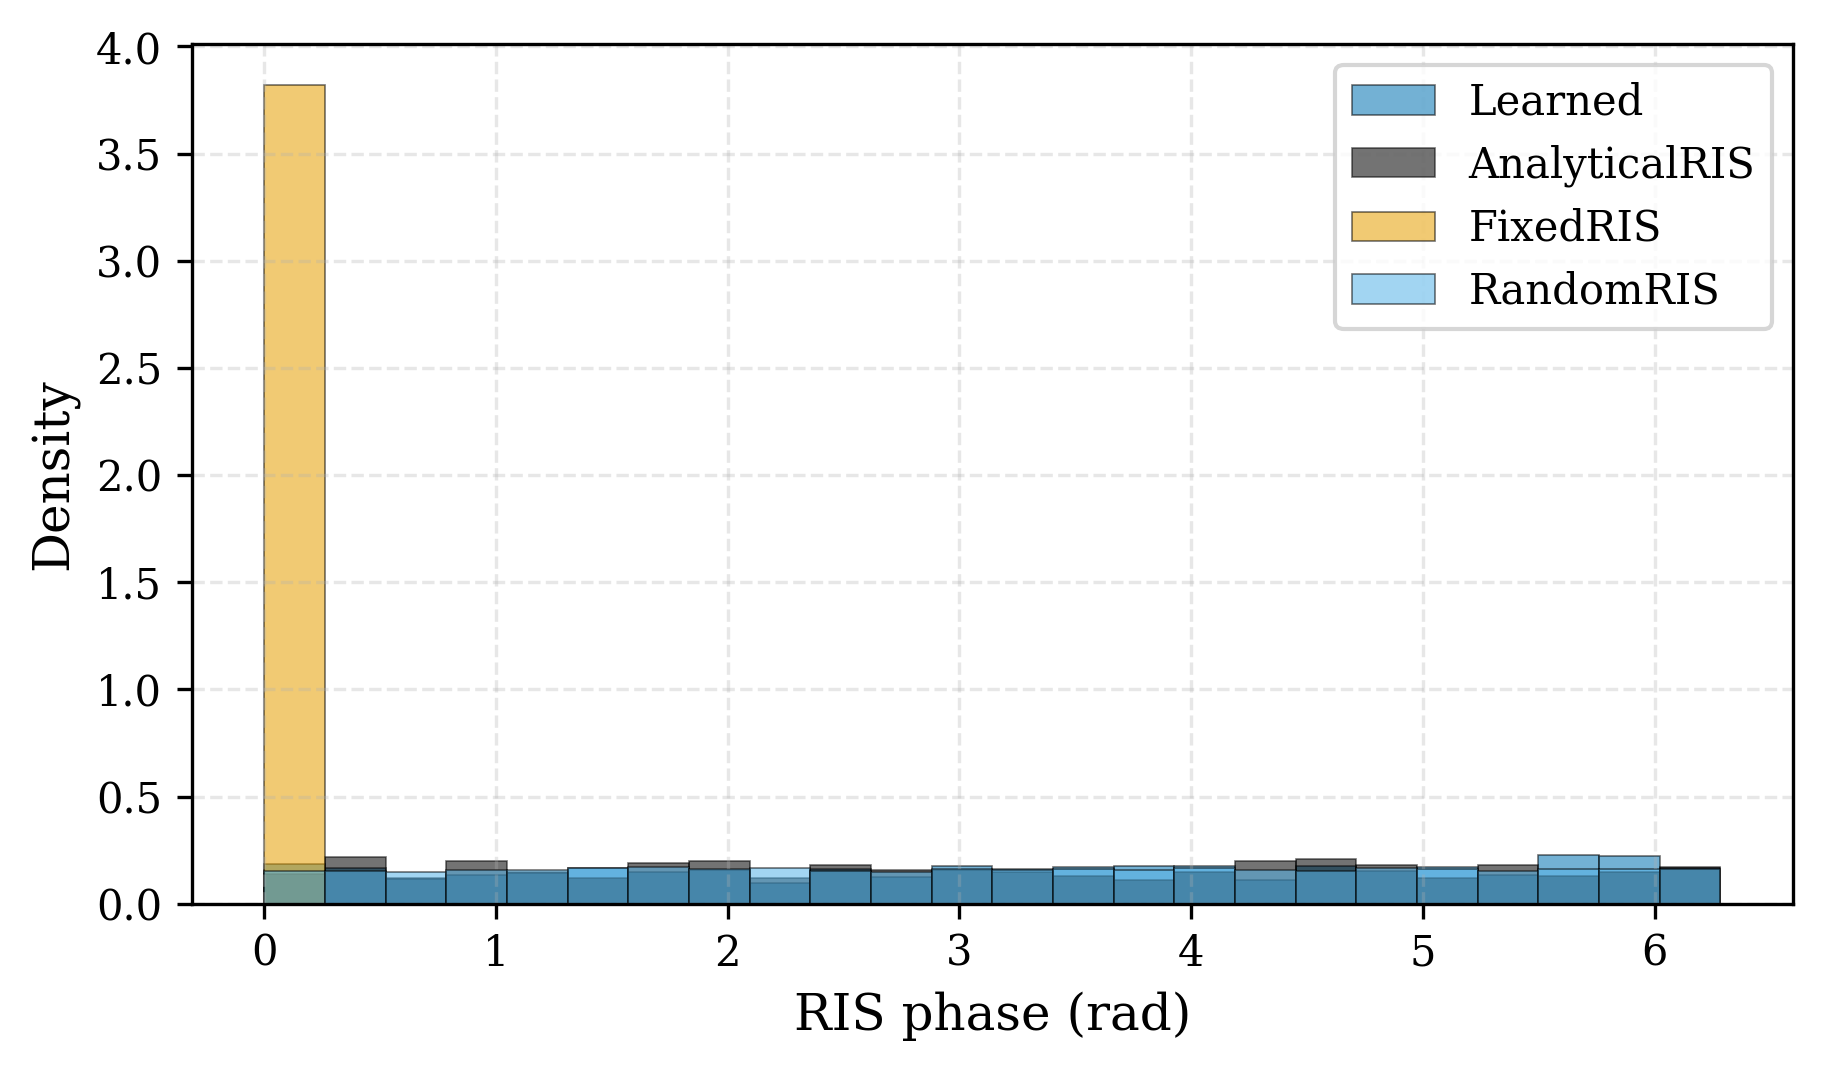

--- |h_eff| Distribution (mong đợi: Learned có mean cao hơn) ---


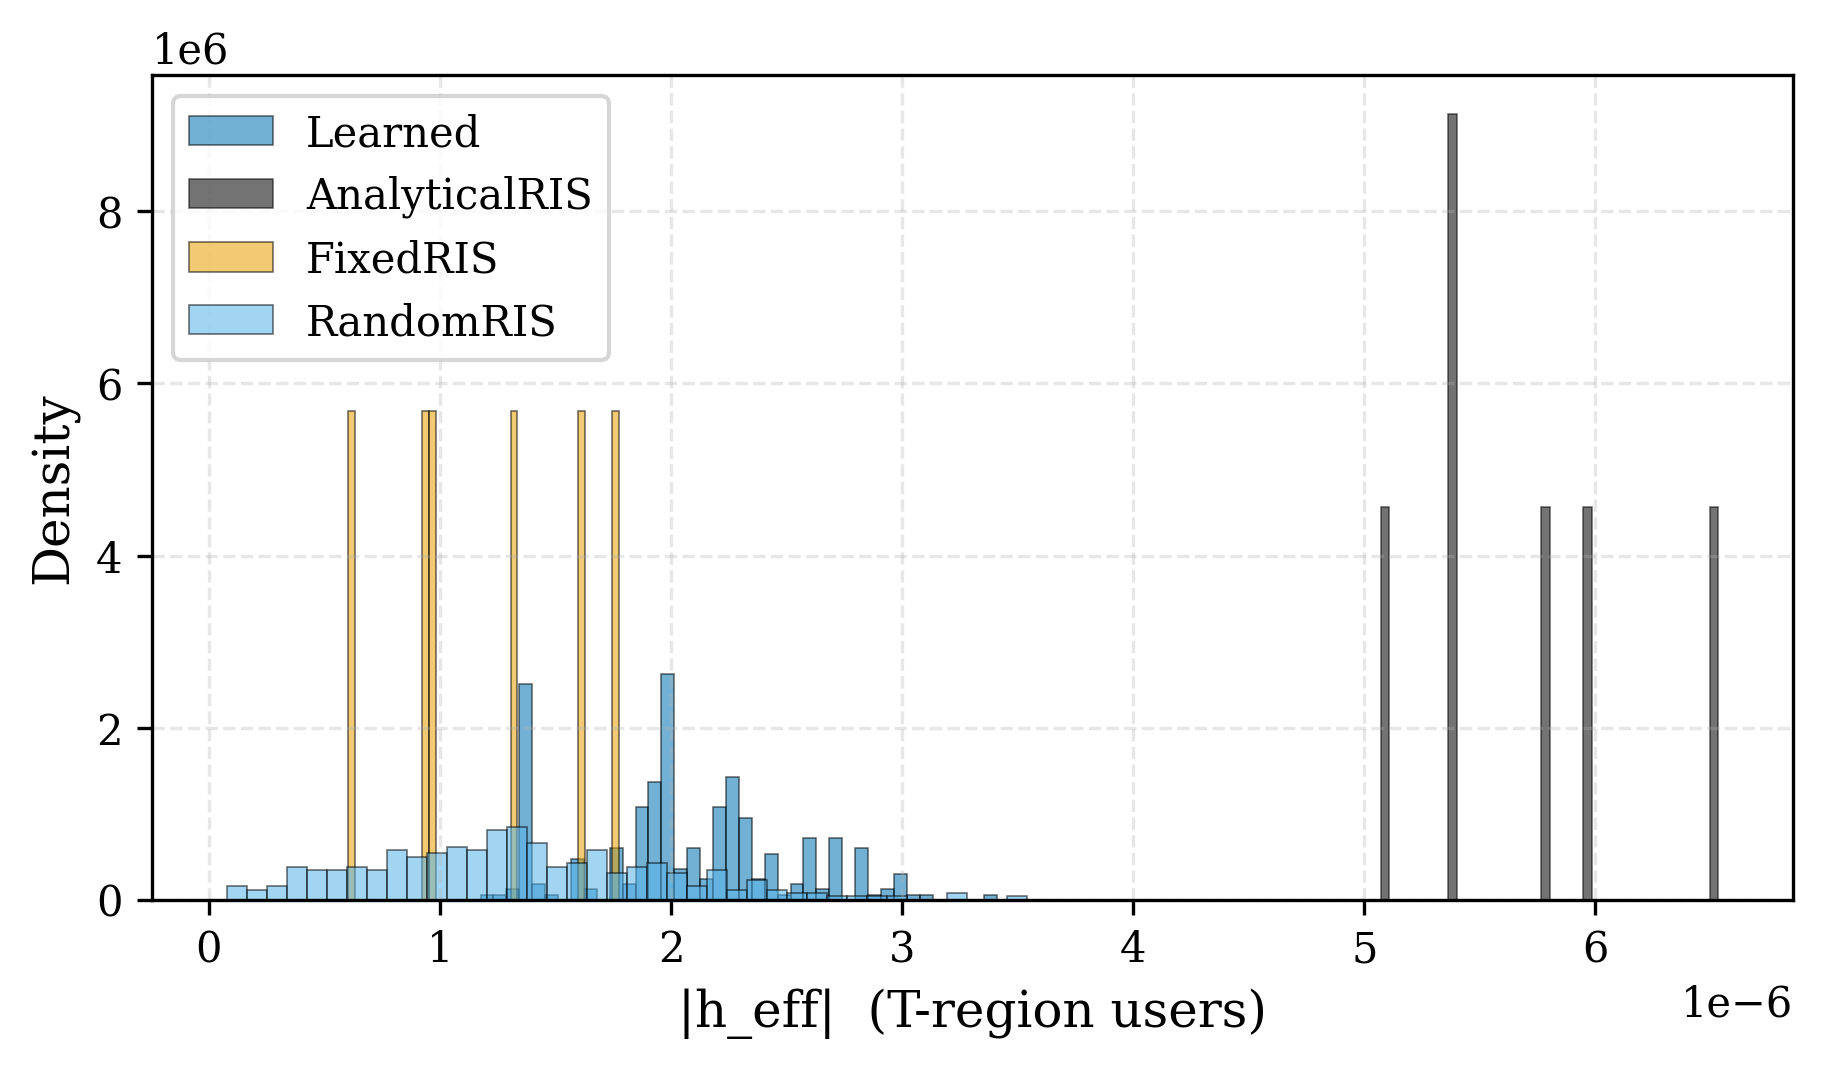

In [9]:
if "MADDPG" in trained_main:
    print("\n========== Nghiên cứu loại bỏ (Ablation Study - 8 cells) ==========")
    maddpg_lam = trained_main["MADDPG"].get("trained_qos_lambda")
    abl = ablation_study(trained_main["MADDPG"]["agent"],
                         trained_main["MADDPG"]["obs_norm"], cfg,
                         qos_lambda=maddpg_lam)
    
    labels = list(abl.keys())
    means = {k: abl[k]["sum_rate_mean"] for k in labels}
    cis = {k: abl[k]["sum_rate_ci"] for k in labels}
    
    plot_bar(labels, means, out_dir=fig_dir, name="ablation",
             ylabel="Avg. sum-rate (b/s/Hz)", ci=cis)
    
    plot_bar(labels, {k: abl[k]["qos_mean"] for k in labels},
             out_dir=fig_dir, name="ablation_qos",
             ylabel="QoS satisfaction probability",
             ci={k: abl[k]["qos_ci"] for k in labels})
    
    # Tạo DataFrame chi tiết
    df_abl = pd.DataFrame({
        "Cell": labels,
        "SumRate_mean": [abl[k]["sum_rate_mean"] for k in labels],
        "SumRate_CI95": [abl[k]["sum_rate_ci"] for k in labels],
        "QoS_mean":     [abl[k]["qos_mean"] for k in labels],
        "QoS_CI95":     [abl[k]["qos_ci"] for k in labels],
        "RateCommon":   [abl[k]["rate_common"] for k in labels],
        "|h_eff_T|":    [abl[k]["h_eff_abs_T"] for k in labels],
        "PhaseEntropy_T":[abl[k]["phase_entropy_T"] for k in labels],
        "P_c/Pmax":     [abl[k]["common_power_frac"] for k in labels],
    })
    df_abl.to_csv(os.path.join(tab_dir, "ablation.csv"), index=False)
    
    # Hiển thị
    print("--- Sum-rate Ablation (mong đợi: BCD > Learned > Fixed > NoRIS) ---")
    display(Image(filename=os.path.join(fig_dir, "ablation.png")))
    print("--- QoS Ablation ---")
    display(Image(filename=os.path.join(fig_dir, "ablation_qos.png")))
    print("\n--- Bảng kết quả Ablation Study ---")
    display(df_abl)
    
    # Phase histogram + h_eff distribution
    print("\n========== Phase histogram + |h_eff| distribution ==========")
    from main import _collect_phase_and_heff_samples
    phase_samples, heff_samples = _collect_phase_and_heff_samples(
        trained_main["MADDPG"]["agent"], trained_main["MADDPG"]["obs_norm"], cfg, n_steps=300,
    )
    plot_phase_histogram(phase_samples, out_dir=fig_dir, name="phase_histogram")
    plot_h_eff_distribution(heff_samples, out_dir=fig_dir, name="h_eff_distribution")
    
    print("--- Phase Histogram (mong đợi: Learned tập trung hơn Random/Fixed) ---")
    display(Image(filename=os.path.join(fig_dir, "phase_histogram.png")))
    print("--- |h_eff| Distribution (mong đợi: Learned có mean cao hơn) ---")
    display(Image(filename=os.path.join(fig_dir, "h_eff_distribution.png")))
else:
    print("MADDPG không được huấn luyện, bỏ qua Ablation Study.")

### 10. So sánh Hiệu năng giữa các Thuật toán & Kiểm định thống kê (Welch's t-test)

Đánh giá chi tiết qua **5 training seeds × 5 evaluation seeds**.

**📌 Output mong đợi:**
- Bảng so sánh thuật toán với Return, SumRate, QoS, CI
- Bảng Welch's t-test: MADDPG vs mỗi baseline

**🎯 Kết quả mong đợi cho bài báo:**
- MADDPG SumRate **> 2.8** với CI < ±0.10
- MADDPG **Pareto-dominates** TD3 (sum-rate VÀ QoS đều cao hơn)
- p-value MADDPG vs TD3 **< 0.10** (hoặc tốt hơn < 0.05 với 3000 eps)
- p-value MADDPG vs PPO **< 0.05** (PPO degenerate → khác biệt rõ ràng)

In [10]:
print("\n========== So sánh hiệu năng các thuật toán (Đa Seed) ==========")
rows = []
pareto_points = {}
per_seed_returns_per_algo = {}

for algo, runs in trained.items():
    run_rets, run_srs, run_qoss, run_lats, run_lams = [], [], [], [], []
    run_rc, run_htabs, run_pent, run_cfrac = [], [], [], []
    for info in runs:
        lam = info.get("trained_qos_lambda")
        m_run = _eval_multi_seed(info["agent"], algo, info["obs_norm"], cfg,
                                 cfg["evaluation"]["seeds"], qos_lambda=lam)
        run_rets.append(m_run["return_mean"])
        run_srs.append(m_run["sum_rate_mean"])
        run_qoss.append(m_run["qos_mean"])
        run_lats.append(m_run["latency_ms_mean"])
        run_rc.append(m_run["rate_common_mean"])
        run_htabs.append(m_run["h_eff_abs_T_mean"])
        run_pent.append(m_run["phase_entropy_T_mean"])
        run_cfrac.append(m_run["common_power_frac_mean"])
        run_lams.append(lam if lam is not None else float("nan"))
        
    ret_m, ret_ci, _ = confidence_interval(np.array(run_rets))
    sr_m, sr_ci, _   = confidence_interval(np.array(run_srs))
    q_m, q_ci, _     = confidence_interval(np.array(run_qoss))
    lat_m = float(np.mean(run_lats))
    
    rows.append({"Algorithm": algo,
                 "Return": ret_m, "Return_CI": ret_ci,
                 "SumRate": sr_m, "SumRate_CI": sr_ci,
                 "QoS_prob": q_m, "QoS_CI": q_ci,
                 "RateCommon": float(np.mean(run_rc)),
                 "|h_eff_T|":   float(np.mean(run_htabs)),
                 "PhaseEntropy_T": float(np.mean(run_pent)),
                 "P_c/Pmax":    float(np.mean(run_cfrac)),
                 "Latency_ms":  lat_m,
                 "trained_lambda_mean": float(np.nanmean(run_lams)),
                 "N_train_seeds": len(runs)})
    pareto_points[algo] = {"sum_rate_mean": sr_m, "sum_rate_ci": sr_ci,
                           "qos_mean": q_m, "qos_ci": q_ci}
    per_seed_returns_per_algo[algo] = run_rets

df_cmp = pd.DataFrame(rows)
df_cmp.to_csv(os.path.join(tab_dir, "algorithm_comparison.csv"), index=False)
print("\n--- Bảng so sánh thuật toán ---")
display(df_cmp)

# Welch's t-test
print("\n========== Welch's t-test (MADDPG vs baselines) ==========")
if "MADDPG" in trained:
    m_returns = np.array(per_seed_returns_per_algo["MADDPG"], dtype=float)
    sig_rows = []
    for algo, vec in per_seed_returns_per_algo.items():
        if algo == "MADDPG":
            continue
        r = np.array(vec, dtype=float)
        p = welch_ttest_p(m_returns, r)
        sig_rows.append({"Comparison": f"MADDPG vs {algo}",
                         "delta_mean_return": float(m_returns.mean() - r.mean()),
                         "p_value": p,
                         "significant_5pct": p < 0.05,
                         "N_seeds_per_algo": len(training_seeds)})
    df_sig = pd.DataFrame(sig_rows)
    df_sig.to_csv(os.path.join(tab_dir, "significance.csv"), index=False)
    print("  ✅ p < 0.05 → sự khác biệt có ý nghĩa thống kê")
    print("  ⚠️ p > 0.05 → claim dựa trên Pareto-dominance thay vì strict significance")
    display(df_sig)


========== So sánh hiệu năng các thuật toán (Đa Seed) ==========

--- Bảng so sánh thuật toán ---


,Algorithm,Return,Return_CI,SumRate,SumRate_CI,QoS_prob,QoS_CI,RateCommon,|h_eff_T|,PhaseEntropy_T,P_c/Pmax,Latency_ms,trained_lambda_mean,N_train_seeds
0,MADDPG,0.775124,0.451627,2.538703,0.204500,0.338480,0.094473,0.848517,0.000002,2.504136,0.646329,1.283802,15.000000,5
1,DDPG,0.080379,0.780065,1.782533,0.043854,0.203147,0.054383,0.232343,0.000002,2.500948,0.219297,0.484225,15.000000,5
2,TD3,0.917188,0.403242,2.613924,0.307643,0.335093,0.078408,0.875536,0.000002,2.492985,0.604330,0.482963,14.812552,5
3,PPO,3.621417,0.068329,3.031351,0.149779,0.981973,0.024340,1.428299,0.000007,2.496034,0.631385,1.119632,15.000000,5



========== Welch's t-test (MADDPG vs baselines) ==========
  ✅ p < 0.05 → sự khác biệt có ý nghĩa thống kê
  ⚠️ p > 0.05 → claim dựa trên Pareto-dominance thay vì strict significance


,Comparison,delta_mean_return,p_value,significant_5pct,N_seeds_per_algo
0,MADDPG vs DDPG,0.694745,0.073261,False,5
1,MADDPG vs TD3,-0.142065,0.533296,False,5
2,MADDPG vs PPO,-2.846293,0.000047,True,5


### 11. So sánh năng lực thuần túy tại $\lambda = 0$ và Đồ thị Pareto

- **So sánh λ=0**: Loại bỏ thành phần phạt QoS để đánh giá trực tiếp pure capability.
- **Pareto plot**: Vị trí thuật toán trên mặt phẳng Sum-rate × QoS.

**📌 Output mong đợi:**
- Bảng so sánh λ=0: MADDPG Return > TD3 > DDPG
- Đồ thị Pareto: MADDPG ở góc phải-trên (cao SR, cao QoS), TD3 bên dưới


========== So sánh thuật toán tại λ = 0 ==========


/kaggle/input/datasets/duythanhb1909984/star-ris-rsma-maddpg-v14/experiments/train.py:54: RuntimeWarning: [StarRisRsmaEnv] qos_lambda clamped from 0.0000 to 0.3000 (bounds=[0.3, 15.0]). Train/eval reward scales may differ — verify intent.
  env.set_qos_lambda(qos_lambda_override)



--- Bảng so sánh tại λ = 0 (pure capability) ---


,Algorithm,Return_l0,Return_l0_CI,SumRate_l0,SumRate_l0_CI,QoS_l0,QoS_l0_CI
0,MADDPG,2.741189,0.134683,2.529980,0.193251,0.337440,0.101338
1,DDPG,2.488048,0.130990,1.777230,0.039435,0.200907,0.056814
2,TD3,2.758223,0.168859,2.610987,0.310798,0.334613,0.079737
3,PPO,3.625415,0.064676,3.031364,0.149771,0.981973,0.024340



========== Đồ thị Pareto (Sum-rate vs QoS) ==========
  ✅ TỐT nếu: MADDPG ở góc PHẢI-TRÊN (cao SR + cao QoS)
  📋 MADDPG dominate TD3 nếu nằm trên-phải so với TD3


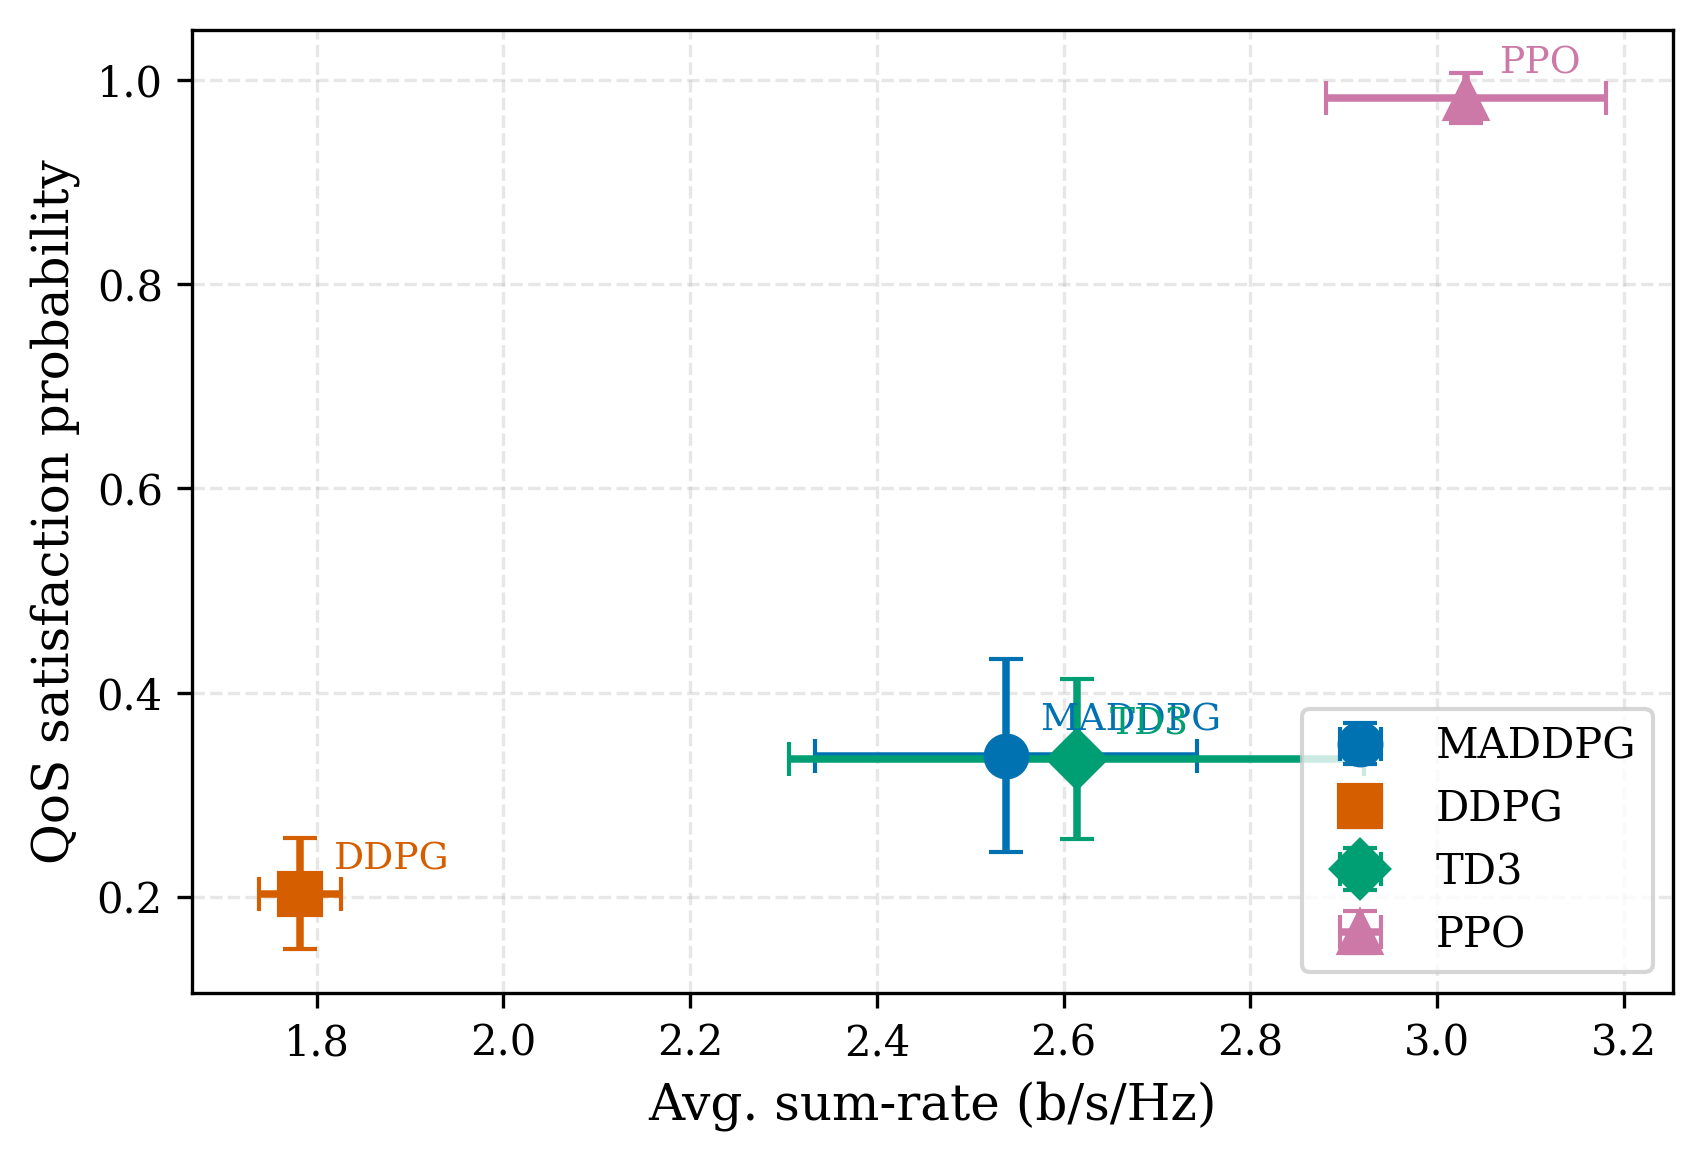

In [11]:
print("\n========== So sánh thuật toán tại λ = 0 ==========")
rows_l0 = []
for algo, runs in trained.items():
    rs, ss, qs = [], [], []
    for info in runs:
        m_run = _eval_multi_seed(info["agent"], algo, info["obs_norm"], cfg,
                                 cfg["evaluation"]["seeds"], qos_lambda=0.0)
        rs.append(m_run["return_mean"])
        ss.append(m_run["sum_rate_mean"])
        qs.append(m_run["qos_mean"])
    r_m, r_ci, _ = confidence_interval(np.array(rs))
    s_m, s_ci, _ = confidence_interval(np.array(ss))
    q_m_l0, q_ci_l0, _ = confidence_interval(np.array(qs))
    rows_l0.append({"Algorithm": algo,
                    "Return_l0": r_m, "Return_l0_CI": r_ci,
                    "SumRate_l0": s_m, "SumRate_l0_CI": s_ci,
                    "QoS_l0": q_m_l0, "QoS_l0_CI": q_ci_l0})

df_cmp_l0 = pd.DataFrame(rows_l0)
df_cmp_l0.to_csv(os.path.join(tab_dir, "algorithm_comparison_lambda0.csv"), index=False)
print("\n--- Bảng so sánh tại λ = 0 (pure capability) ---")
display(df_cmp_l0)

print("\n========== Đồ thị Pareto (Sum-rate vs QoS) ==========")
print("  ✅ TỐT nếu: MADDPG ở góc PHẢI-TRÊN (cao SR + cao QoS)")
print("  📋 MADDPG dominate TD3 nếu nằm trên-phải so với TD3")
plot_pareto(pareto_points, out_dir=fig_dir, name="pareto_sr_vs_qos")
display(Image(filename=os.path.join(fig_dir, "pareto_sr_vs_qos.png")))

### 12. Tạo Báo cáo Kết quả Tóm tắt (`results_summary.md`)

Tự động sinh báo cáo kết quả vào file `results_summary.md`.

**📌 Output mong đợi:** Nội dung báo cáo hoàn chỉnh in ra màn hình.

In [12]:
from main import _write_report

report_path = os.path.join(out_root, "results_summary.md")
_write_report(report_path, cfg, df_cmp, sr_vs_p, qos, lat,
              abl if "MADDPG" in trained else None)

print(f"Báo cáo kết quả đã được ghi vào: {report_path}")
print("\n--- Nội dung báo cáo tóm tắt ---")
with open(report_path, "r", encoding="utf-8") as f:
    print(f.read())

Báo cáo kết quả đã được ghi vào: /kaggle/working/results_summary.md

--- Nội dung báo cáo tóm tắt ---
# Results Summary — DRL Resource Allocation in STAR-RIS Assisted RSMA Networks
## 1. System Setup
- SISO downlink, K = 4 users (K_R = 3), N = 32 STAR-RIS elements (ES mode).
- P_max = 30.0 dBm, noise = -90.0 dBm, per-user QoS = 0.3 b/s/Hz, T-blockage = 25.0 dB.
- Reward: quadratic QoS with adaptive Lagrangian λ (init 1.0, target satisfaction 0.5).
## 2. Algorithm Comparison (5-seed deterministic eval)
```
Algorithm   Return  Return_CI  SumRate  SumRate_CI  QoS_prob   QoS_CI  RateCommon  |h_eff_T|  PhaseEntropy_T  P_c/Pmax  Latency_ms  trained_lambda_mean  N_train_seeds
   MADDPG 0.775124   0.451627 2.538703    0.204500  0.338480 0.094473    0.848517   0.000002        2.504136  0.646329    1.283802            15.000000              5
     DDPG 0.080379   0.780065 1.782533    0.043854  0.203147 0.054383    0.232343   0.000002        2.500948  0.219297    0.484225            15.000000    